# Analysis - Test - Model

In [136]:
# Useful libraries
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn import preprocessing


In [4]:
# Getting Datasets
df_portefeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_finalmmations = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")
df_reclamations = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_interactions = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_impayes = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")

/tmp/ipykernel_3368/3274524437.py:2: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")


In [5]:
# Import the aggregation module
from utils import TransformData, ModelData
from merge_and_agregation import aggregate_impayes, aggregate_interaction, aggregate_consommations, aggregate_reclamations

In [6]:
# Aggretation
df1 = aggregate_consommations(df_finalmmations)
df2 = aggregate_reclamations(df_reclamations)
df3 = aggregate_interaction(df_interactions)
df4 = aggregate_impayes(df_impayes)

/home/onyxia/work/bdc-alptis-g2/bdc-alptis-g2/merge_and_agregation.py:251: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("client_code").apply(build_info_dict).reset_index(drop=True)
/home/onyxia/work/bdc-alptis-g2/bdc-alptis-g2/merge_and_agregation.py:376: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_interaction_historique_mail = df_mail.groupby("client_code").apply(


In [7]:
# Final dataset
df_final = (
    df_portefeuille
    .set_index("client_code")
    .join(df1.set_index("client_code"), how="left")
    .join(df2.set_index("client_code"), how="left")
    .join(df3.set_index("client_code"), how="left")
    .join(df4.set_index("client_code"), how="left")
    .reset_index()
)

In [8]:
# Shape dataset
df_final.shape

(132576, 135)

In [9]:
# Shape dataset
list(df_final.columns)

['client_code',
 'client_age_souscripteur',
 'client_sexe_souscripteur',
 'client_ro_souscripteur',
 'client_code_postal',
 'client_departement',
 'client_departement_avant_changement_12_mois',
 'client_a_conjoint',
 'client_nb_enfants',
 'client_structure_familiale',
 'client_nb_assures_contrat',
 'client_a_garantie_prevoyance',
 'client_produit',
 'client_garantie_base',
 'client_garantie_base_plus_options',
 'client_millesime_tarifaire_produit',
 'client_zone_tarifaire',
 'client_type_zone_tarifaire',
 'client_est_contrat_madelin',
 'client_date_debut_effet_garantie',
 'client_anciennete_contrat_annees',
 'client_cotisations_annualisees_n_moins2',
 'client_cotisations_annualisees_n_moins1',
 'client_cotisations_annualisees_n',
 'client_cotisations_annualisees_n_plus1',
 'client_mode_paiement',
 'client_frequence_paiement',
 'client_nom_banque',
 'client_nps_date_reponse_n',
 'client_nps_note_reco_n',
 'client_nps_verbatim_n',
 'client_nps_date_reponse_n_moins1',
 'client_nps_note_re

In [10]:
# Describe the dataset
TransformData.grouptype(df_final)

{'int64': ['client_code',
  'client_age_souscripteur',
  'client_code_postal',
  'client_departement',
  'client_a_garantie_prevoyance',
  'client_est_contrat_madelin',
  'client_anciennete_contrat_annees',
  'client_cotisations_annualisees_n_plus1',
  'courtier_code_partenaire',
  'courtier_code_apporteur',
  'courtier_est_escompte',
  'courtier_nb_affaires_n_moins1',
  'courtier_nb_radiations_n_moins1',
  'courtier_nb_affaires_n_moins2',
  'courtier_nb_radiations_n_moins2',
  'target_resiliation_6mois'],
 'object': ['client_sexe_souscripteur',
  'client_ro_souscripteur',
  'client_structure_familiale',
  'client_produit',
  'client_garantie_base',
  'client_garantie_base_plus_options',
  'client_millesime_tarifaire_produit',
  'client_zone_tarifaire',
  'client_type_zone_tarifaire',
  'client_date_debut_effet_garantie',
  'client_mode_paiement',
  'client_frequence_paiement',
  'client_nom_banque',
  'client_nps_date_reponse_n',
  'client_nps_verbatim_n',
  'client_nps_date_reponse_n

In [11]:
# Format the variables
df_final['client_code'] = df_final['client_code'].astype(str)
df_final['client_code_postal'] = df_final['client_code_postal'].astype(str).str.zfill(5)
df_final['client_departement'] = df_final['client_departement'].astype(str).str.zfill(2)
df_final['client_departement_avant_changement_12_mois'] = df_final['client_departement_avant_changement_12_mois'].astype(str)
df_final['client_a_garantie_prevoyance'] = df_final['client_a_garantie_prevoyance'].astype(str)
df_final['client_est_contrat_madelin'] = df_final['client_est_contrat_madelin'].astype(str)
df_final['courtier_est_escompte'] = df_final['courtier_est_escompte'].astype(str)
df_final['client_a_conjoint'] = df_final['client_a_conjoint'].astype(str)
df_final['courtier_code_partenaire'] = df_final['courtier_code_partenaire'].astype(str)
df_final['courtier_code_apporteur'] = df_final['courtier_code_apporteur'].astype(str)
df_final['courtier_code_avant_changement_12_mois'] = df_final['courtier_code_avant_changement_12_mois'].astype(str)
df_final['client_nb_enfants'] = df_final['client_nb_enfants'].astype(int)
df_final['client_nb_assures_contrat'] = df_final['client_nb_assures_contrat'].astype(int)

## int
#df_final['nb_decomptes_hospitalisation'] = df_final['nb_decomptes_hospitalisation'].astype(int)
df_final['nb_decomptes_soins_medicaux'] = df_final['nb_decomptes_soins_medicaux'].fillna(0).astype(int)
df_final['nb_decomptes_pharmacie'] = df_final['nb_decomptes_pharmacie'].fillna(0).astype(int)
df_final['nb_decomptes_optique'] = df_final['nb_decomptes_optique'].fillna(0).astype(int)
df_final['nb_decomptes_dentaire'] = df_final['nb_decomptes_dentaire'].fillna(0).astype(int)
df_final['nb_jours_forfait_journalier'] = df_final['nb_jours_forfait_journalier'].fillna(0).astype(int)
df_final['nb_jours_chambre_particuliere'] = df_final['nb_jours_chambre_particuliere'].fillna(0).astype(int)
df_final['nb_protheses_dentaires'] = df_final['nb_protheses_dentaires'].fillna(0).astype(int)
df_final['nb_decomptes'] = df_final['nb_decomptes'].fillna(0).astype(int)
df_final['nb_decomptes_divers'] = df_final['nb_decomptes_divers'].fillna(0).astype(int)

## Columns from secondary dataset
for elem in list(df_final.select_dtypes(include=['float', 'int']).columns):
    df_final[elem] = df_final[elem].fillna(0).astype(float)

# running data type analysis
TransformData.grouptype(df_final)

# running data type analysis
TransformData.grouptype(df_final)

{'object': ['client_code',
  'client_sexe_souscripteur',
  'client_ro_souscripteur',
  'client_code_postal',
  'client_departement',
  'client_departement_avant_changement_12_mois',
  'client_a_conjoint',
  'client_structure_familiale',
  'client_a_garantie_prevoyance',
  'client_produit',
  'client_garantie_base',
  'client_garantie_base_plus_options',
  'client_millesime_tarifaire_produit',
  'client_zone_tarifaire',
  'client_type_zone_tarifaire',
  'client_est_contrat_madelin',
  'client_date_debut_effet_garantie',
  'client_mode_paiement',
  'client_frequence_paiement',
  'client_nom_banque',
  'client_nps_date_reponse_n',
  'client_nps_verbatim_n',
  'client_nps_date_reponse_n_moins1',
  'client_nps_verbatim_n_moins1',
  'courtier_code_partenaire',
  'courtier_code_apporteur',
  'courtier_code_avant_changement_12_mois',
  'courtier_reseau_courtage',
  'courtier_segmentation_interne',
  'courtier_type_commission',
  'courtier_est_escompte',
  'annee_mois_paiement',
  'info_par_ann

## Testing MCA

In [31]:
# preprocessing before acm
df_acm = df_final[[x for x in list(df_final.columns) if x.startswith('client') | x.startswith('nb_decomptes_') | x.startswith('remb_alptis_') | x.startswith('reste_a_charge_')]]
df_acm = ModelData.acm_preprocess_categorical(
    df_acm, 
    exclude=['client_code', 'client_code_postal', 'client_departement', 'client_nom_banque', 'client_departement_avant_changement_12_mois']
    )
df_acm = ModelData.acm_preprocess_numerical(df_acm)

Liste des colonnes modifiées : ['client_a_garantie_prevoyance', 'client_est_contrat_madelin']
Liste des colonnes modifiées : ['client_age_souscripteur', 'client_nb_enfants', 'client_nb_assures_contrat', 'client_anciennete_contrat_annees', 'client_cotisations_annualisees_n_moins2', 'client_cotisations_annualisees_n_moins1', 'client_cotisations_annualisees_n', 'client_cotisations_annualisees_n_plus1', 'client_nps_note_reco_n', 'client_nps_note_reco_n_moins1', 'nb_decomptes_hospitalisation', 'nb_decomptes_soins_medicaux', 'nb_decomptes_pharmacie', 'nb_decomptes_optique', 'nb_decomptes_dentaire', 'nb_decomptes_divers', 'remb_alptis_hospitalisation', 'remb_alptis_soins_medicaux', 'remb_alptis_pharmacie', 'remb_alptis_optique', 'remb_alptis_dentaire', 'remb_alptis_divers', 'reste_a_charge_hospitalisation', 'reste_a_charge_soins_medicaux', 'reste_a_charge_pharmacie', 'reste_a_charge_optique', 'reste_a_charge_dentaire', 'reste_a_charge_divers']


In [32]:
# info df_acm
df_acm = df_acm[[x for x in list(df_acm.columns) if not 'nps' in x ]]
df_acm.shape

(132576, 41)

In [33]:
# info df_acm
df_acm.isna().sum()

client_age_souscripteur                    0
client_sexe_souscripteur                   0
client_ro_souscripteur                     0
client_a_conjoint                          0
client_nb_enfants                          0
client_structure_familiale                 0
client_nb_assures_contrat                  0
client_a_garantie_prevoyance               0
client_produit                             0
client_garantie_base                       0
client_garantie_base_plus_options          0
client_millesime_tarifaire_produit         0
client_zone_tarifaire                      0
client_type_zone_tarifaire                 0
client_est_contrat_madelin                 0
client_date_debut_effet_garantie           0
client_anciennete_contrat_annees           0
client_cotisations_annualisees_n_moins2    0
client_cotisations_annualisees_n_moins1    0
client_cotisations_annualisees_n           0
client_cotisations_annualisees_n_plus1     0
client_mode_paiement                       0
client_fre

In [62]:
# df_acm selection
df_acm = df_acm[['client_age_souscripteur', 'client_sexe_souscripteur', 'client_nb_assures_contrat', 'client_a_garantie_prevoyance', 'client_produit', 'client_zone_tarifaire', 
'client_anciennete_contrat_annees', 'client_cotisations_annualisees_n_moins2', 'client_cotisations_annualisees_n_moins1', 'client_cotisations_annualisees_n', 
'client_cotisations_annualisees_n_plus1', 'nb_decomptes_hospitalisation', 'nb_decomptes_soins_medicaux', 'nb_decomptes_pharmacie', 'nb_decomptes_optique', 'nb_decomptes_dentaire', 'nb_decomptes_divers',
'remb_alptis_hospitalisation', 'remb_alptis_soins_medicaux', 'remb_alptis_pharmacie', 'remb_alptis_optique', 'remb_alptis_dentaire', 'remb_alptis_divers', 'reste_a_charge_hospitalisation',
'reste_a_charge_soins_medicaux', 'reste_a_charge_pharmacie', 'reste_a_charge_optique', 'reste_a_charge_dentaire', 'reste_a_charge_divers']
]

In [63]:
df_acm.columns

Index(['client_age_souscripteur', 'client_sexe_souscripteur',
       'client_nb_assures_contrat', 'client_a_garantie_prevoyance',
       'client_produit', 'client_zone_tarifaire',
       'client_anciennete_contrat_annees',
       'client_cotisations_annualisees_n_moins2',
       'client_cotisations_annualisees_n_moins1',
       'client_cotisations_annualisees_n',
       'client_cotisations_annualisees_n_plus1',
       'nb_decomptes_hospitalisation', 'nb_decomptes_soins_medicaux',
       'nb_decomptes_pharmacie', 'nb_decomptes_optique',
       'nb_decomptes_dentaire', 'nb_decomptes_divers',
       'remb_alptis_hospitalisation', 'remb_alptis_soins_medicaux',
       'remb_alptis_pharmacie', 'remb_alptis_optique', 'remb_alptis_dentaire',
       'remb_alptis_divers', 'reste_a_charge_hospitalisation',
       'reste_a_charge_soins_medicaux', 'reste_a_charge_pharmacie',
       'reste_a_charge_optique', 'reste_a_charge_dentaire',
       'reste_a_charge_divers'],
      dtype='object')

In [15]:
# launch ACM
!pip install prince
import prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.2/731.2 kB 16.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 47.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 63.2 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [prince]2m5/7 [altair]learn]


In [94]:
# Intsantiate MCA
mca = prince.MCA(
    n_components= 20,
    n_iter= 20,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=10
)
mca = mca.fit(df_acm.sample(5000, random_state=1))

In [95]:
# Summary of factorial axis
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.254,2.87%,2.87%
1,0.123,1.39%,4.26%
2,0.113,1.28%,5.54%
3,0.102,1.15%,6.69%
4,0.095,1.07%,7.76%
5,0.084,0.95%,8.70%
6,0.079,0.89%,9.60%
7,0.077,0.87%,10.47%
8,0.074,0.83%,11.30%


In [96]:
# Contributions (col)
df_acm_contribution_col = mca.column_contributions_
df_acm_contribution_col = df_acm_contribution_col * 100
df_acm_contribution_col


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
client_age_souscripteur__client_age_0,6.252616e-01,5.753854e-01,1.082276e-01,8.662997e+00,1.443760e-01,1.448163e+00,9.077090e-01,1.013001e-01,3.403384e-02,2.029614e-02,5.214913e-01,2.831826e-03,5.556248e-02,3.184479e-02,1.149543e-01,2.293311e-02,3.231356e-02,2.639699e-04,2.672212e-03,1.036647e-02
client_age_souscripteur__client_age_1,1.914816e-02,7.257145e-02,6.861705e-01,9.175381e-01,4.329273e-01,1.106806e-01,1.354750e-01,3.302849e-01,1.710193e-02,6.436298e-02,2.780829e-02,2.362937e-03,1.633136e-01,3.328807e-01,7.120809e-02,5.237657e-03,4.790884e-03,1.530122e-02,5.675345e-03,2.746171e-02
client_age_souscripteur__client_age_2,6.756043e-03,1.021903e+00,7.687501e-02,2.092239e-01,6.772542e-02,6.913894e-02,3.253093e-01,8.458127e-03,1.794074e-01,1.285323e-01,7.740626e-01,4.274145e-02,6.763917e-02,1.496627e-03,7.968423e-03,2.465472e-01,8.162946e-04,2.104178e-02,3.424902e-04,9.876926e-04
client_age_souscripteur__client_age_3,2.510575e-01,2.099778e-01,1.406041e-02,1.946401e+00,3.537864e-03,2.140091e-01,7.415195e-05,5.469719e-03,9.079316e-02,9.871763e-02,2.392189e-01,1.040166e-01,3.302218e-02,2.849238e-01,1.099883e-01,2.647156e-05,1.336677e-02,4.509633e-04,1.326382e-03,8.210091e-03
client_age_souscripteur__client_age_4,1.388486e-01,1.679836e-01,3.136070e-02,5.048039e+00,4.478392e-01,1.893480e-02,1.375466e-04,9.578584e-01,1.704757e-01,2.133777e-01,7.118596e-01,6.404815e-02,7.438326e-02,2.459793e-02,1.088931e-01,1.850812e-01,1.708715e-03,1.649407e-04,8.735042e-05,2.127232e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reste_a_charge_optique__reste_a_ch_0,3.585182e-01,1.066086e-01,1.528991e-03,7.681875e-01,3.647945e-03,9.357368e-02,6.266061e-01,2.568408e-02,3.744510e-02,6.655935e-02,4.760209e-03,9.796488e-02,2.066186e-01,4.022665e-02,3.672444e-03,1.333887e-02,4.045708e-03,4.165608e-03,3.567603e-04,3.431846e-03
reste_a_charge_optique__reste_a_ch_1,1.393770e+00,4.144500e-01,5.944082e-03,2.986395e+00,1.418170e-02,3.637757e-01,2.435985e+00,9.984905e-02,1.455710e-01,2.587552e-01,1.850572e-02,3.808469e-01,8.032474e-01,1.563846e-01,1.427694e-02,5.185602e-02,1.572804e-02,1.619416e-02,1.386936e-03,1.334159e-02
reste_a_charge_dentaire__reste_a_ch_0,2.064490e-62,1.112872e-62,1.211496e-62,3.286725e-62,1.062464e-61,8.270299e-61,1.921069e-62,1.519051e-60,4.312076e-61,2.380407e-61,4.622711e-61,1.338983e-63,2.701948e-61,7.790573e-61,7.217743e-66,1.452293e-60,2.095292e-61,2.107300e-61,8.974016e-61,2.113678e-62
reste_a_charge_divers__reste_a_ch_0,6.176334e-01,1.913360e-01,7.671087e-02,3.739081e-03,1.349948e-01,1.965570e-02,1.532464e-01,9.456172e-02,2.276204e-01,1.996902e-03,1.055871e-02,9.450126e-05,1.383752e-04,2.284239e-02,6.432770e-05,8.380194e-05,6.920620e-04,8.911886e-04,1.763328e-03,1.854227e-03


------  Analyse de la variable 0 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 4.5 
Unique values : 282.0


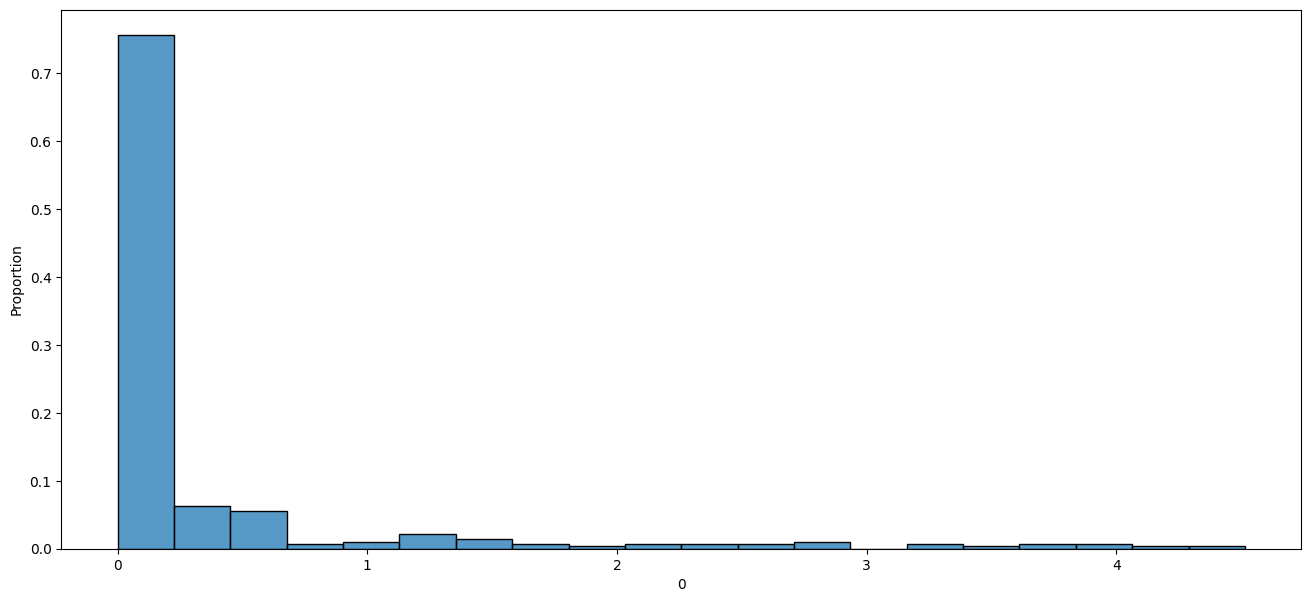

------  Analyse de la variable 1 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 9.4 
Unique values : 282.0


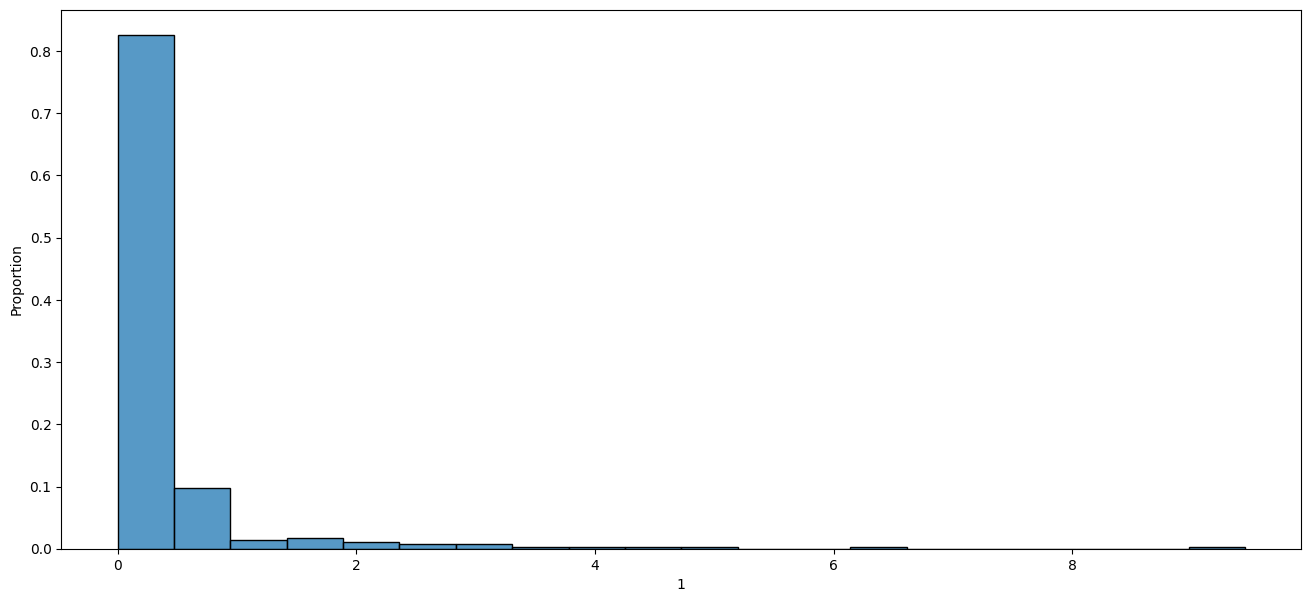

------  Analyse de la variable 2 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 13.0 
Unique values : 282.0


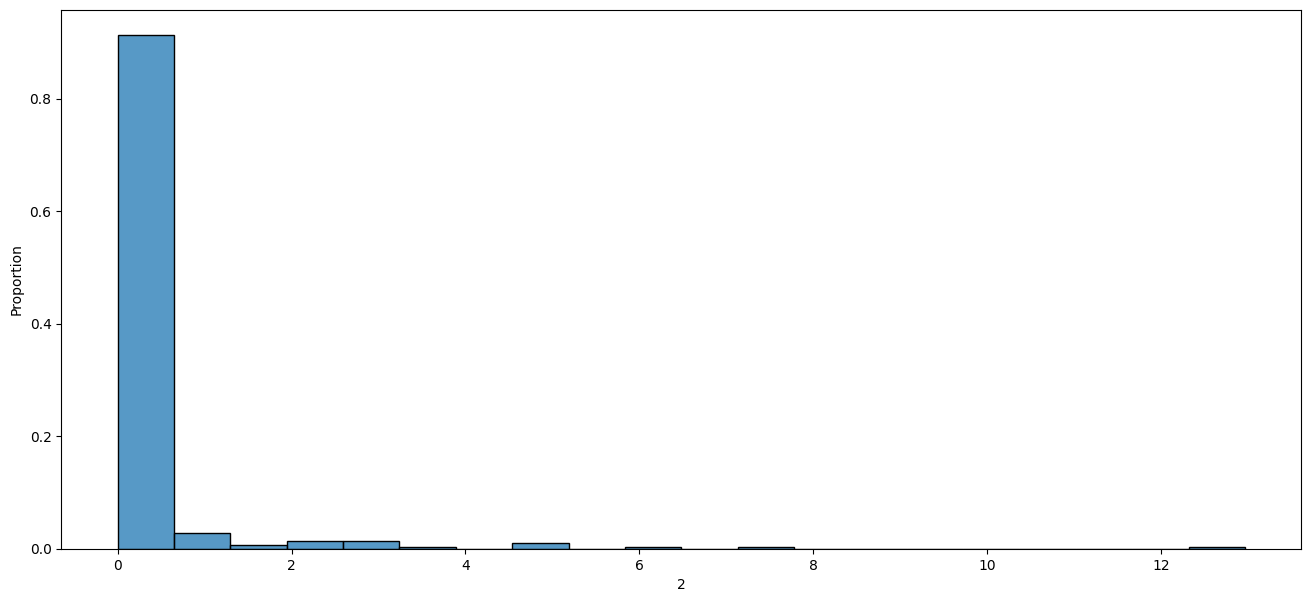

------  Analyse de la variable 3 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 8.7 
Unique values : 282.0


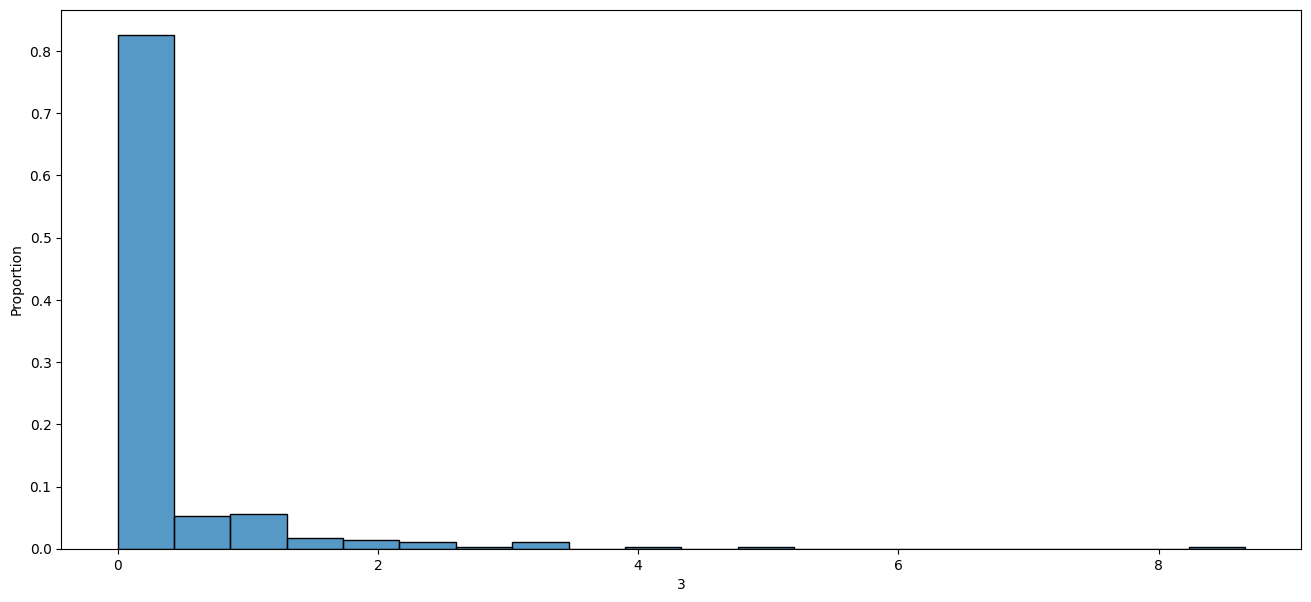

------  Analyse de la variable 4 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 5.6 
Unique values : 282.0


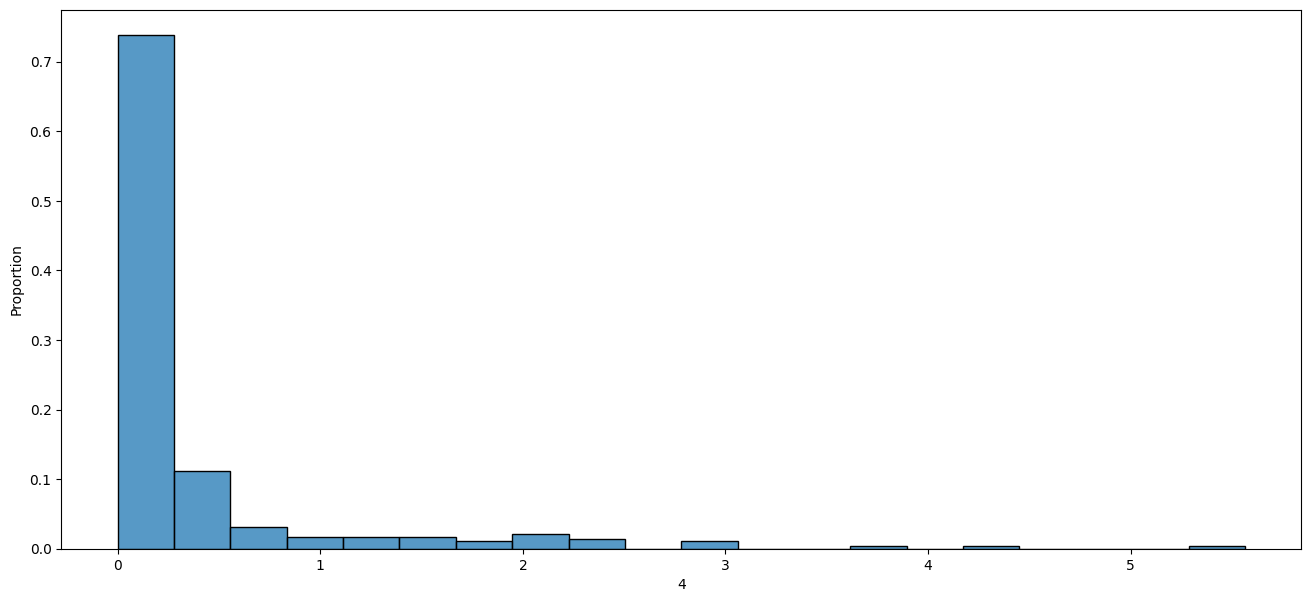

------  Analyse de la variable 5 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 13.9 
Unique values : 282.0


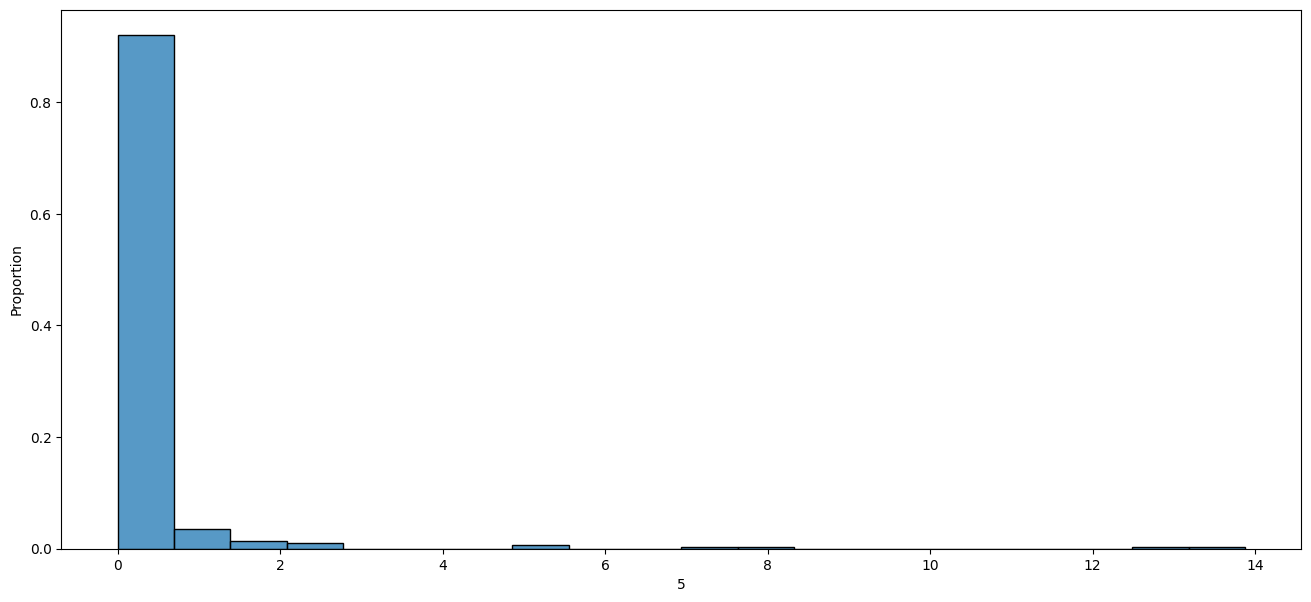

------  Analyse de la variable 6 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 9.3 
Unique values : 283.0


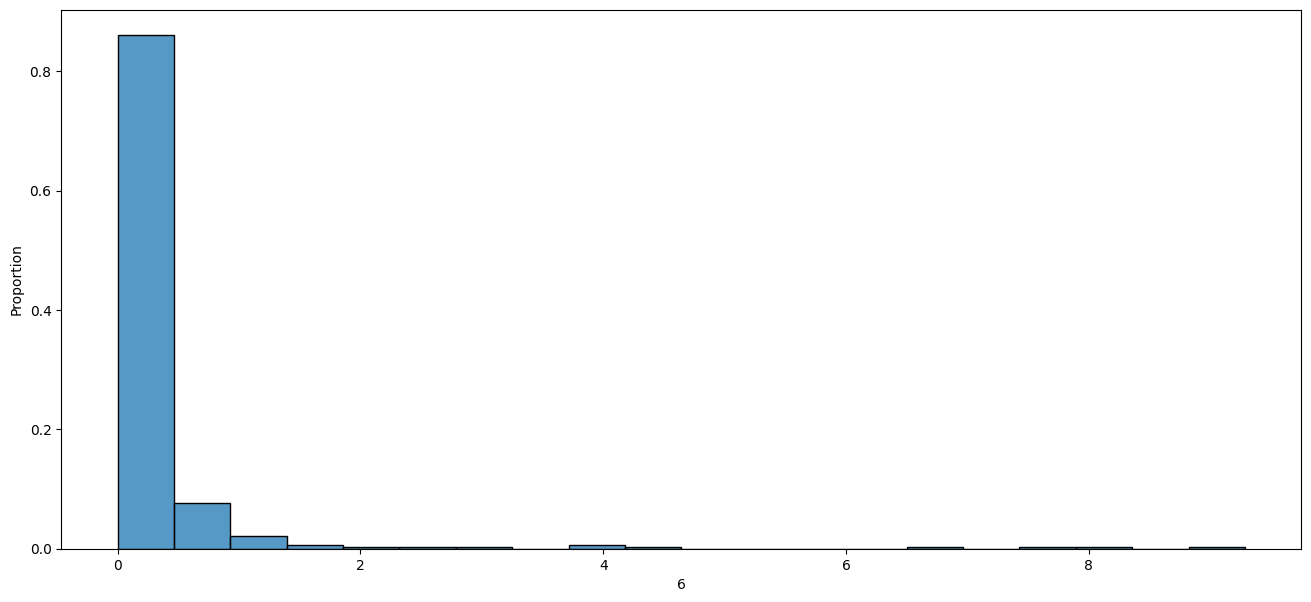

------  Analyse de la variable 7 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 5.9 
Unique values : 282.0


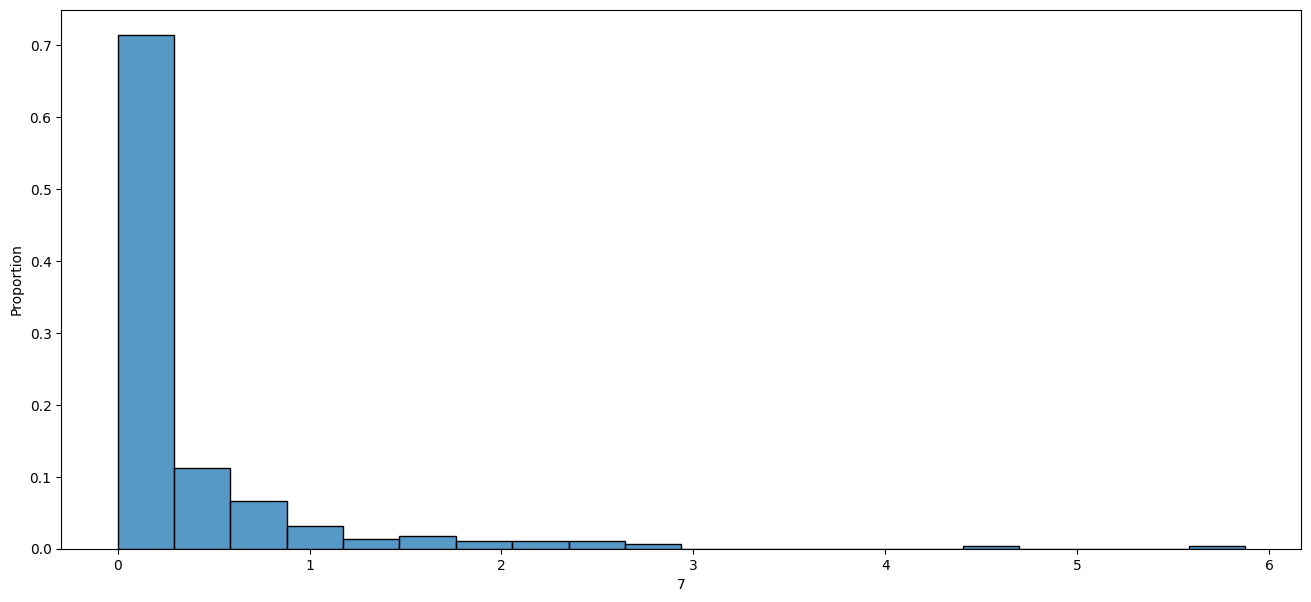

------  Analyse de la variable 8 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 10.6 
Unique values : 283.0


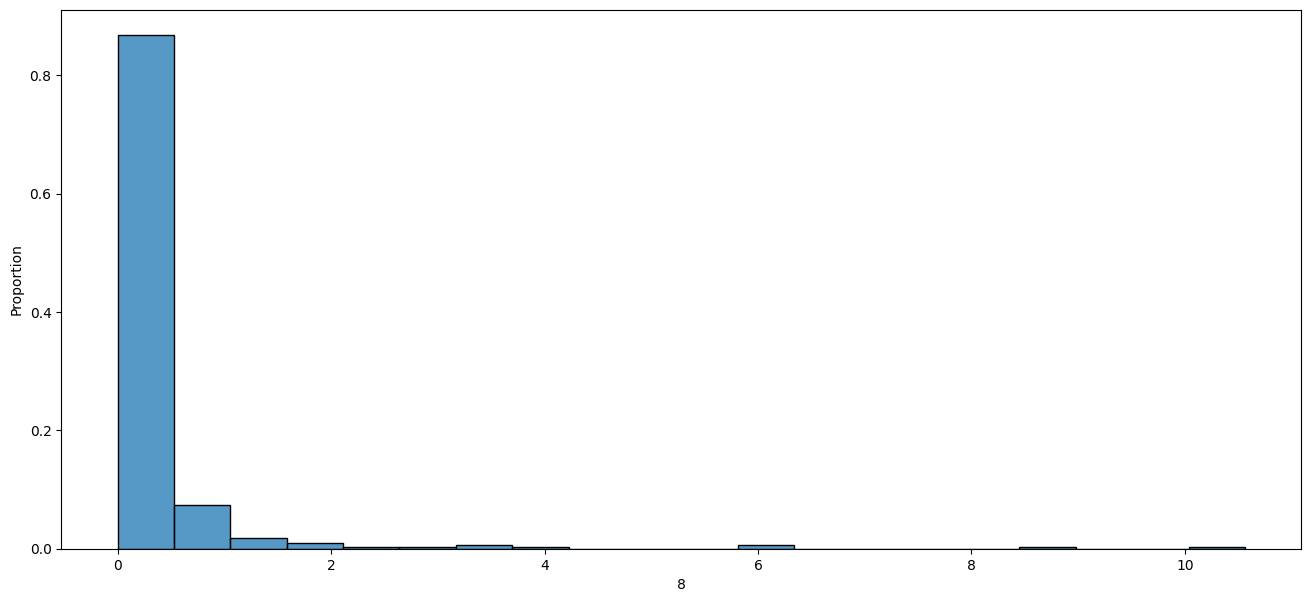

------  Analyse de la variable 9 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 6.0 
Unique values : 282.0


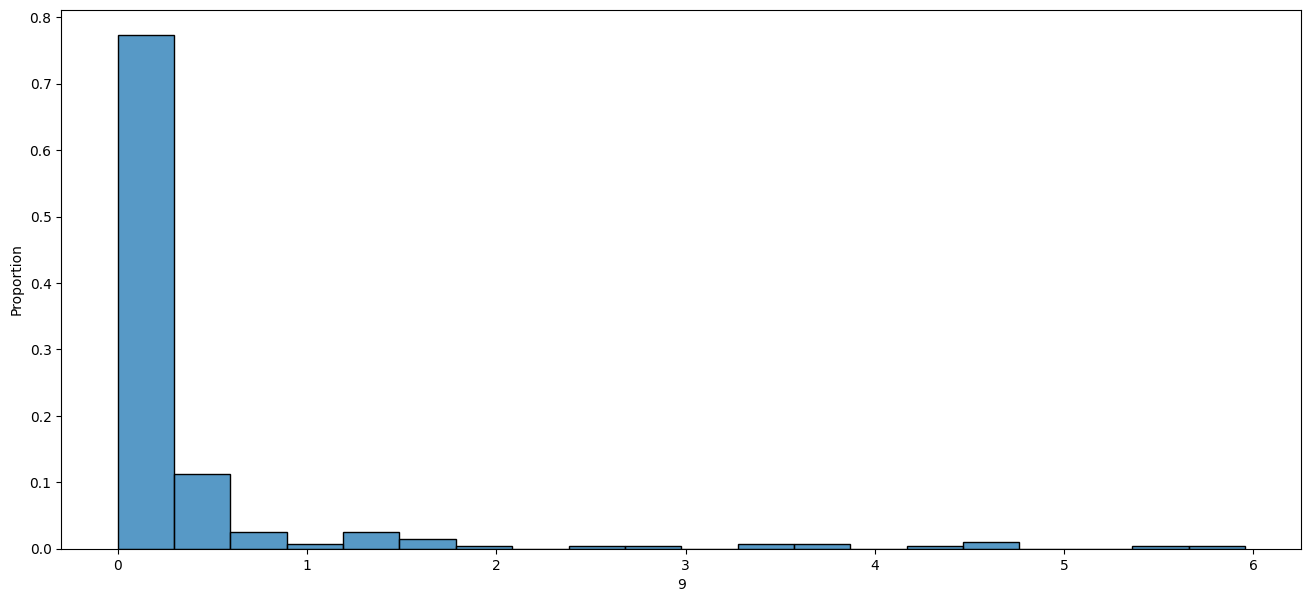

------  Analyse de la variable 10 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 10.3 
Unique values : 283.0


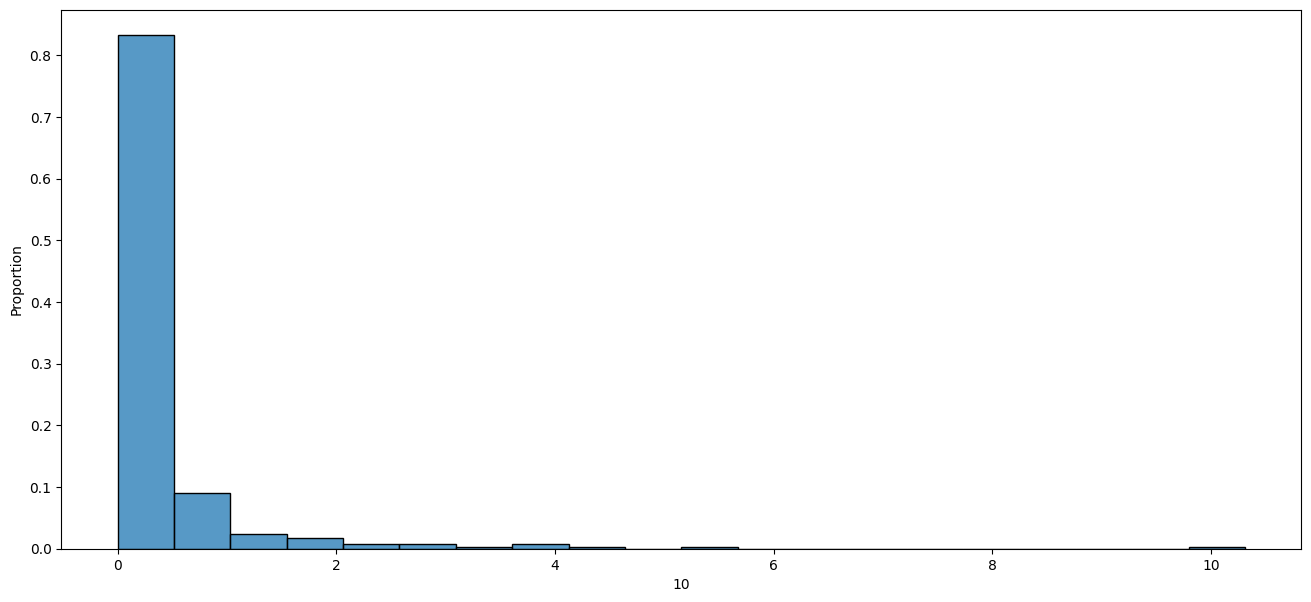

------  Analyse de la variable 11 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 23.3 
Unique values : 283.0


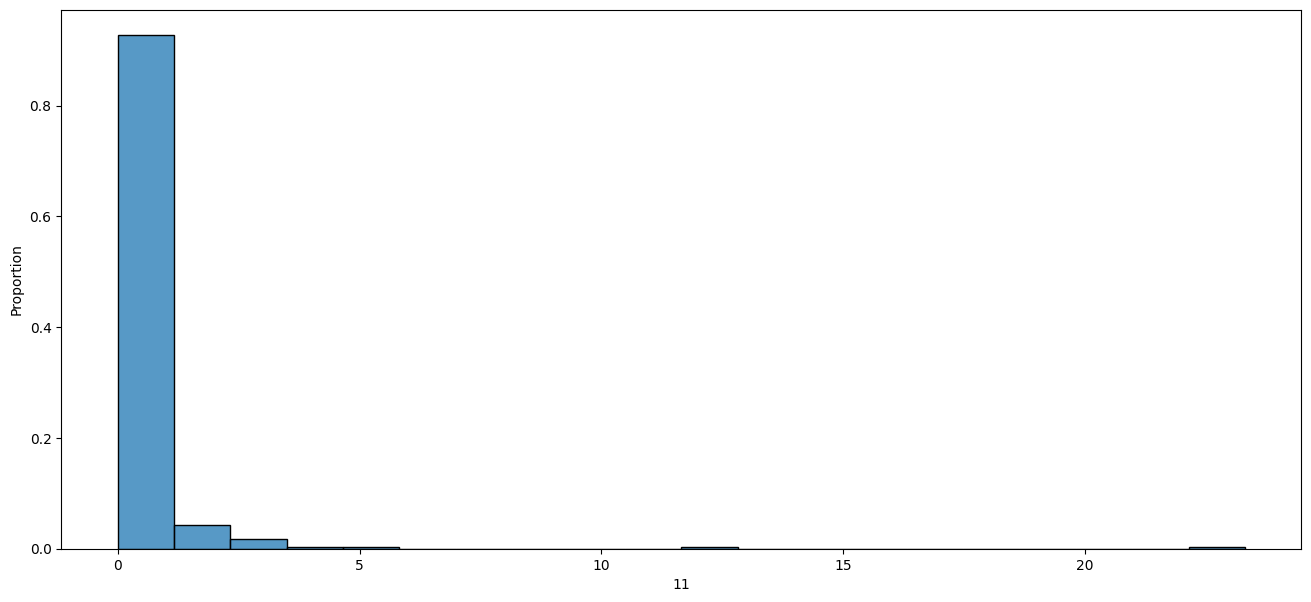

------  Analyse de la variable 12 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.1 
Maximum : 7.5 
Unique values : 283.0


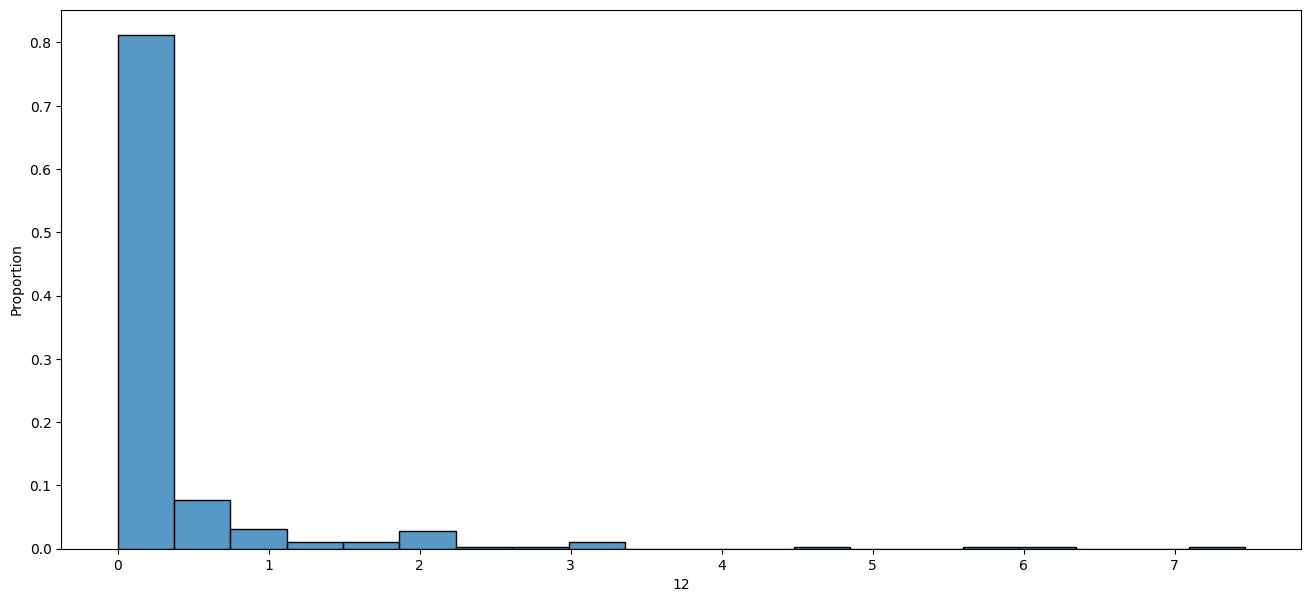

------  Analyse de la variable 13 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 8.1 
Unique values : 283.0


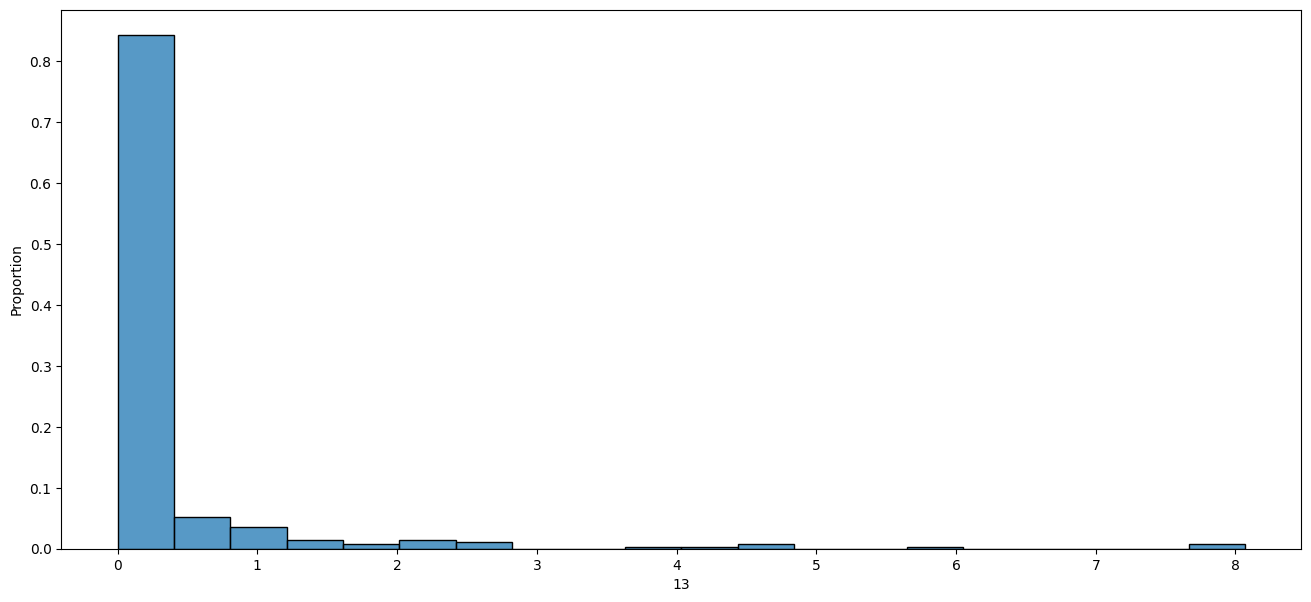

------  Analyse de la variable 14 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 16.0 
Unique values : 283.0


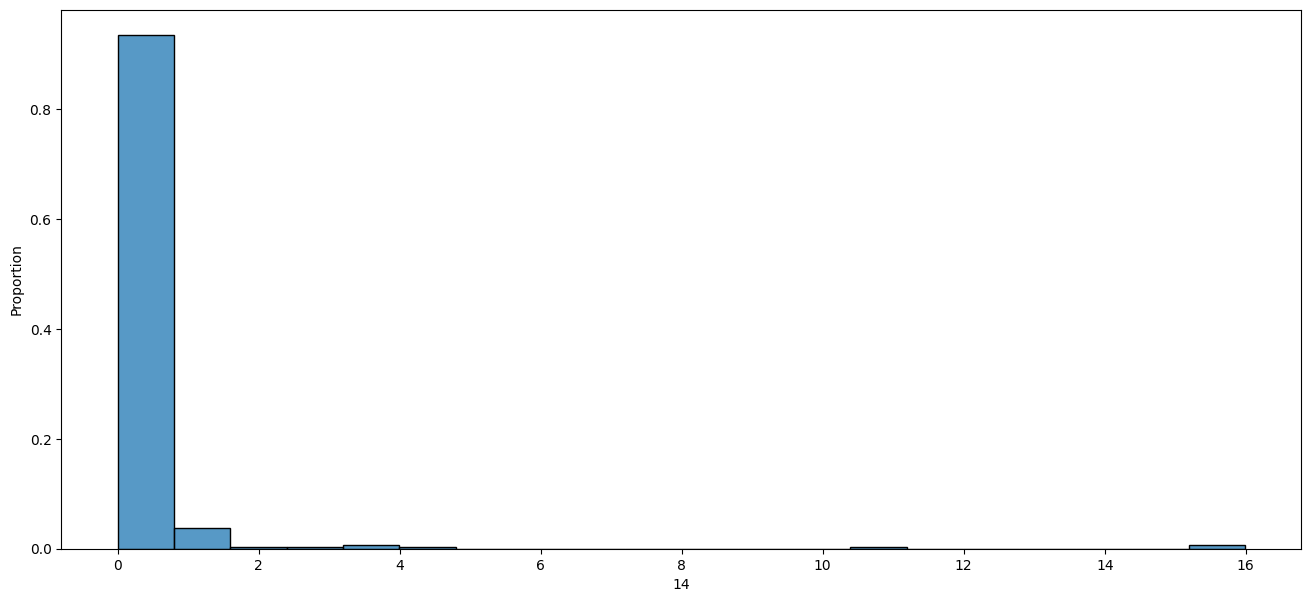

------  Analyse de la variable 15 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 8.6 
Unique values : 283.0


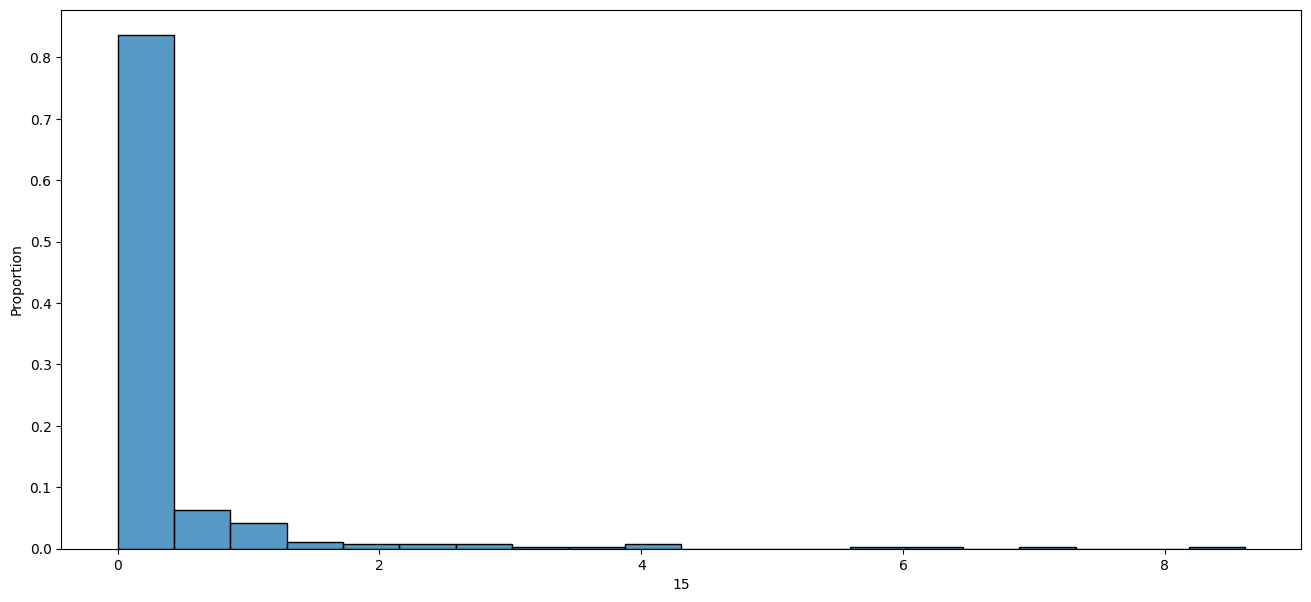

------  Analyse de la variable 16 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 11.7 
Unique values : 283.0


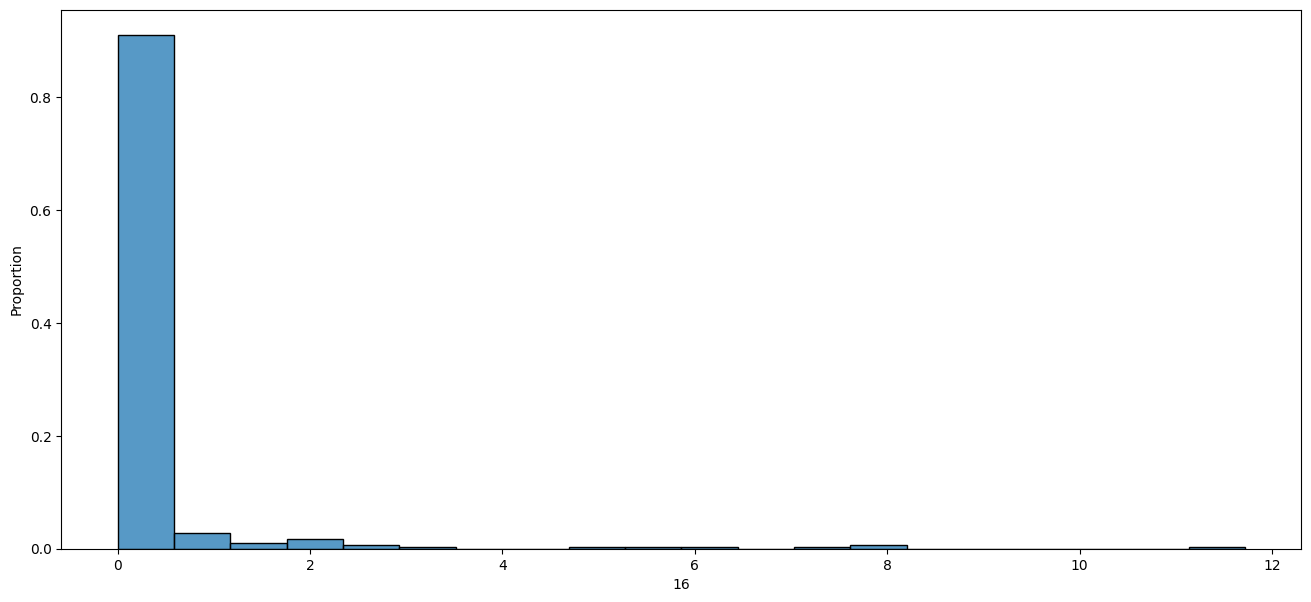

------  Analyse de la variable 17 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 21.6 
Unique values : 283.0


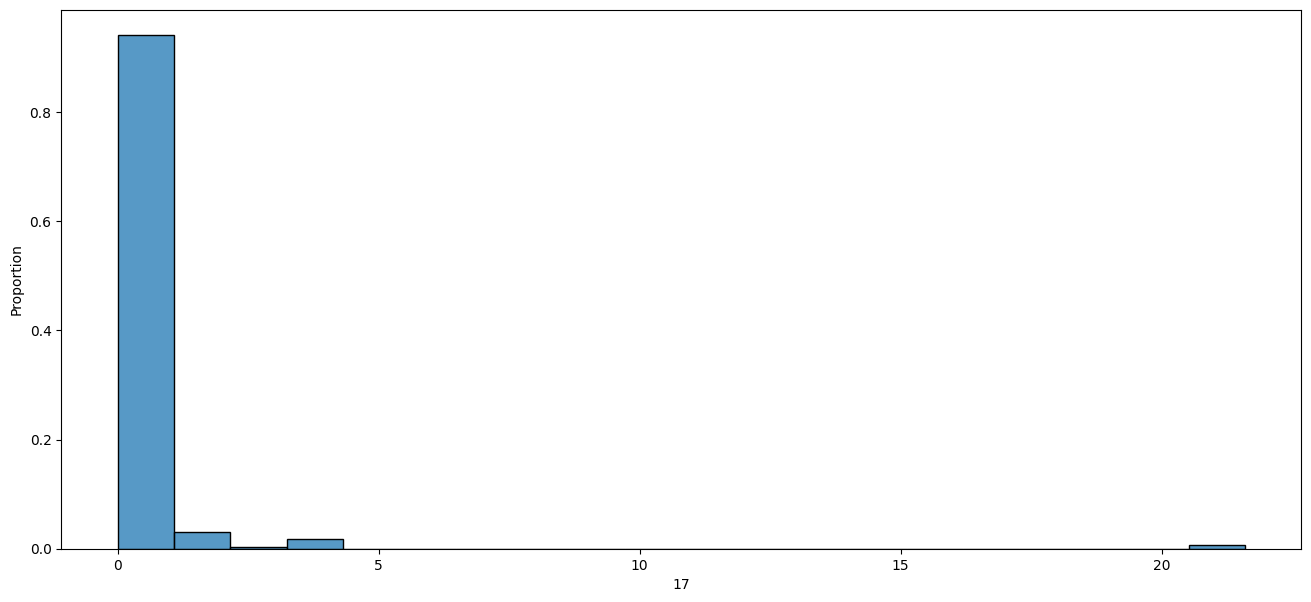

------  Analyse de la variable 18 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 15.9 
Unique values : 283.0


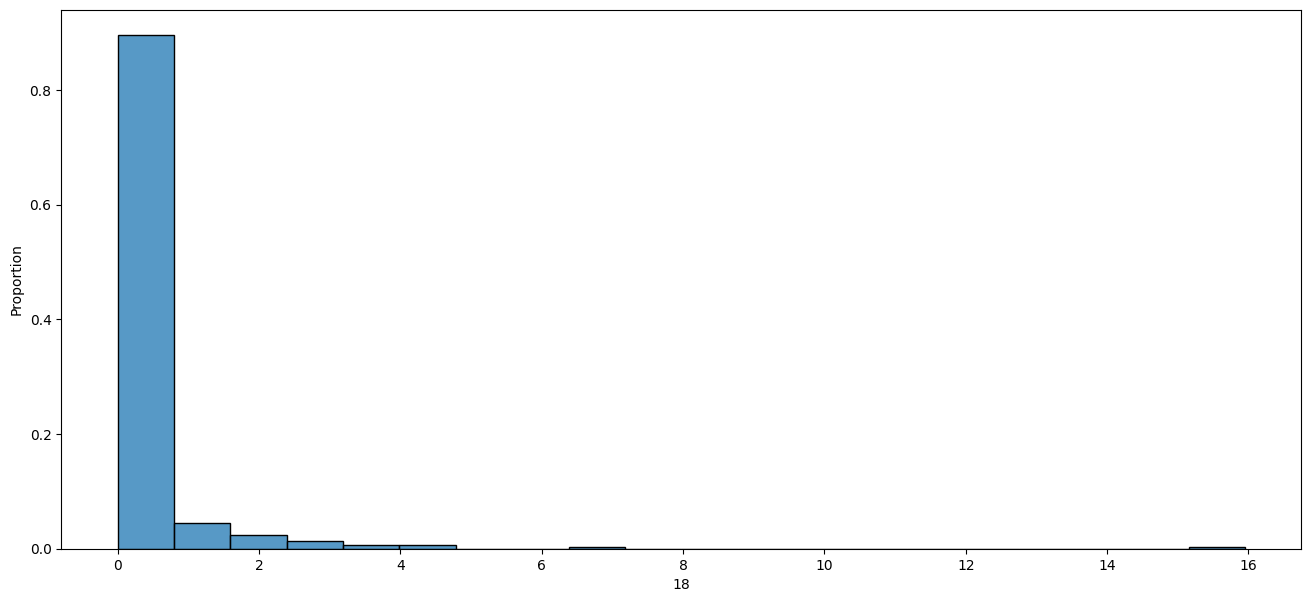

------  Analyse de la variable 19 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.3 
Médiane : 0.0 
Maximum : 11.5 
Unique values : 282.0


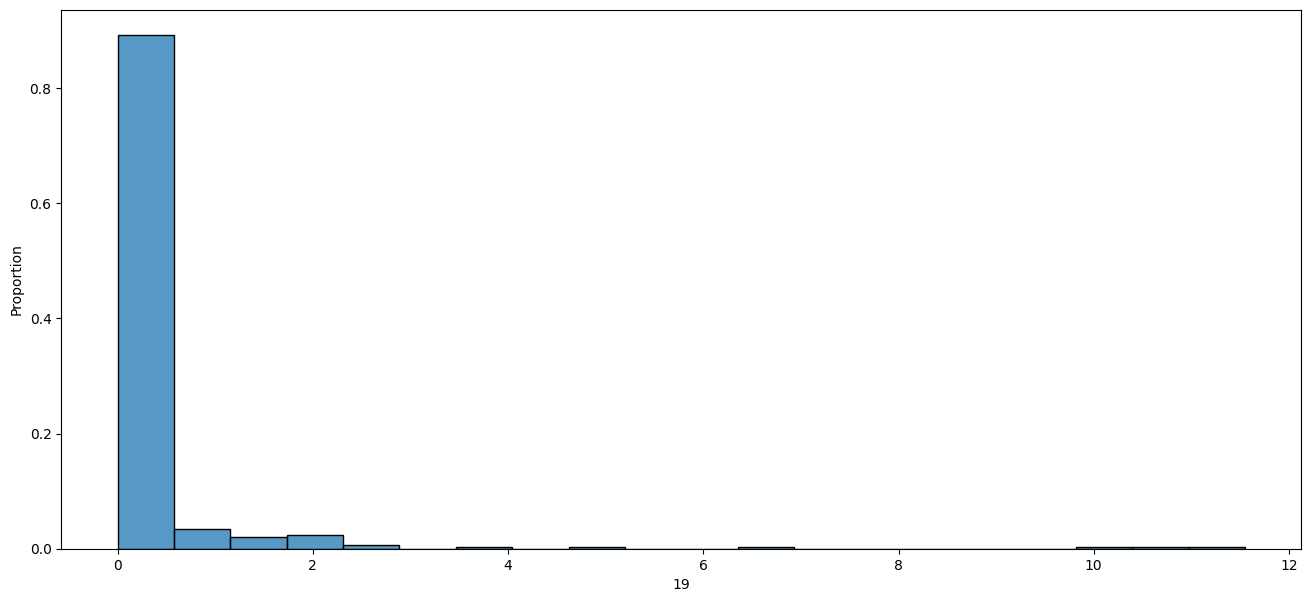

In [97]:
TransformData.plotnum(df_acm_contribution_col, list(df_acm_contribution_col.columns))

In [98]:
# Contributions (row)
df_acm_contribution_row = mca.row_contributions_
df_acm_contribution_row = df_acm_contribution_row * 100
df_acm_contribution_row

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
46725,0.000482,0.003338,0.097214,0.001881,0.000102,0.015931,0.001380,0.043442,0.004478,0.004295,4.386649e-03,0.000041,0.006672,0.000686,0.002675,0.001046,0.000157,0.000964,0.000206,0.001239
53151,0.001530,0.002180,0.029671,0.102216,0.000545,0.026247,0.012027,0.006078,0.007532,0.019813,3.865079e-03,0.001278,0.014131,0.002081,0.004007,0.003196,0.001505,0.000647,0.000439,0.001076
86643,0.044543,0.009852,0.047573,0.001004,0.000073,0.004982,0.006881,0.005462,0.002104,0.001894,3.178037e-04,0.003346,0.000681,0.002173,0.001207,0.000441,0.000193,0.000024,0.000058,0.000505
52263,0.001389,0.006056,0.089741,0.000024,0.007229,0.004981,0.002383,0.011510,0.005762,0.012093,4.509182e-04,0.001984,0.001615,0.000069,0.002167,0.001394,0.000799,0.000008,0.000067,0.000009
119223,0.038212,0.002480,0.036142,0.005262,0.003224,0.011272,0.000844,0.000544,0.002454,0.000193,4.906072e-08,0.000028,0.000042,0.000273,0.000229,0.000067,0.000054,0.000138,0.000005,0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90484,0.000666,0.014503,0.037256,0.000499,0.007344,0.000025,0.010837,0.000109,0.012260,0.008719,7.755294e-03,0.007942,0.000179,0.000884,0.000391,0.002150,0.000115,0.000838,0.000021,0.000691
10968,0.094528,0.102638,0.003043,0.016198,0.002495,0.000004,0.016038,0.061204,0.005057,0.064955,2.236187e-03,0.012759,0.027130,0.005385,0.112603,0.062977,0.068786,0.003060,0.081947,0.039840
127805,0.030329,0.000770,0.003587,0.021733,0.011297,0.022776,0.011204,0.006591,0.000006,0.005713,1.030937e-02,0.000071,0.001621,0.000018,0.000637,0.002533,0.000002,0.000002,0.000070,0.004035
33891,0.004146,0.007635,0.030160,0.029105,0.041404,0.022320,0.009511,0.028350,0.000331,0.003999,4.419312e-04,0.000313,0.002082,0.000111,0.002583,0.000234,0.000167,0.000015,0.000466,0.000027


------  Analyse de la variable 0 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 0.2 
Unique values : 4889.0


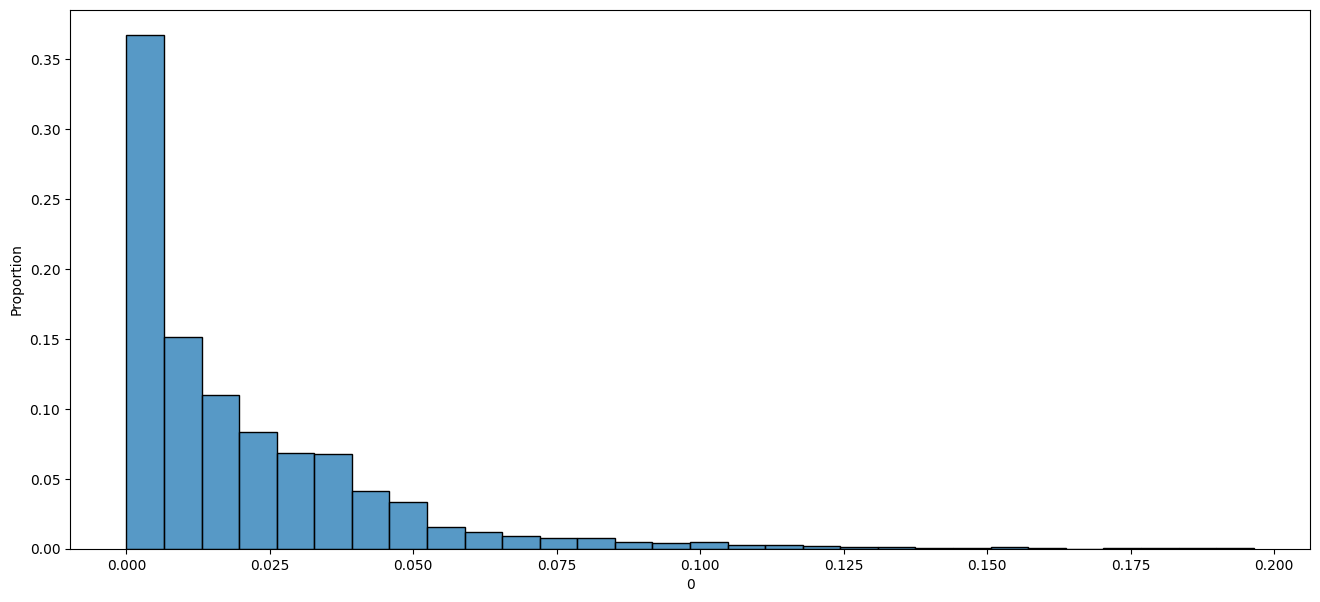

------  Analyse de la variable 1 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 0.3 
Unique values : 4889.0


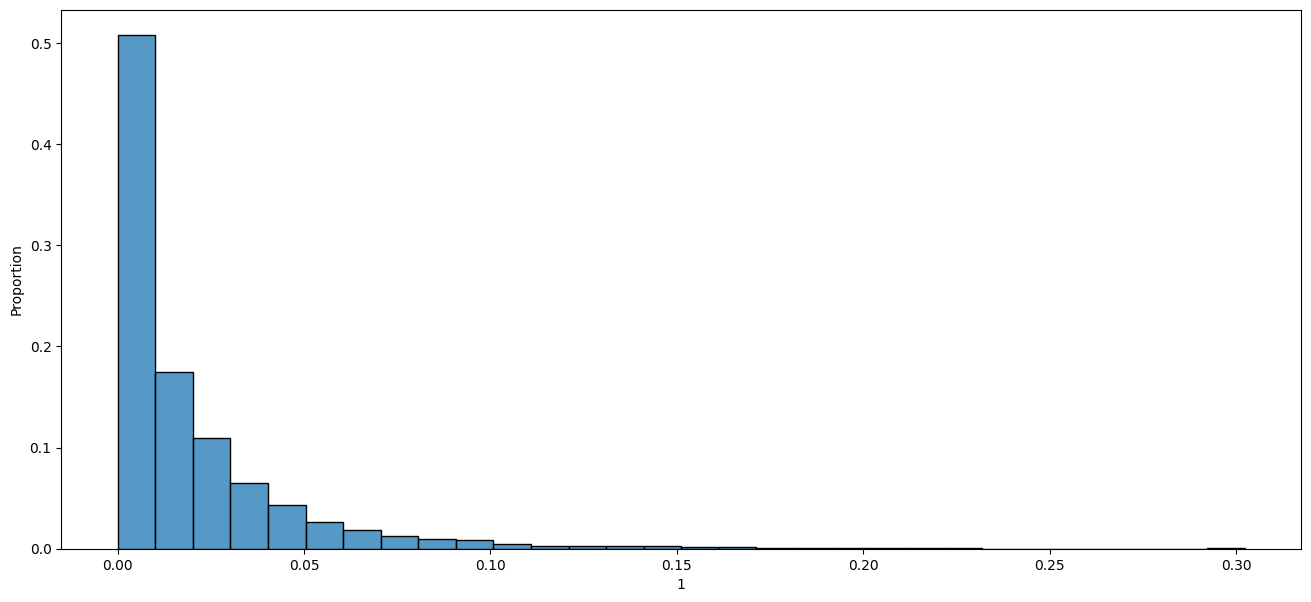

------  Analyse de la variable 2 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 0.2 
Unique values : 4887.0


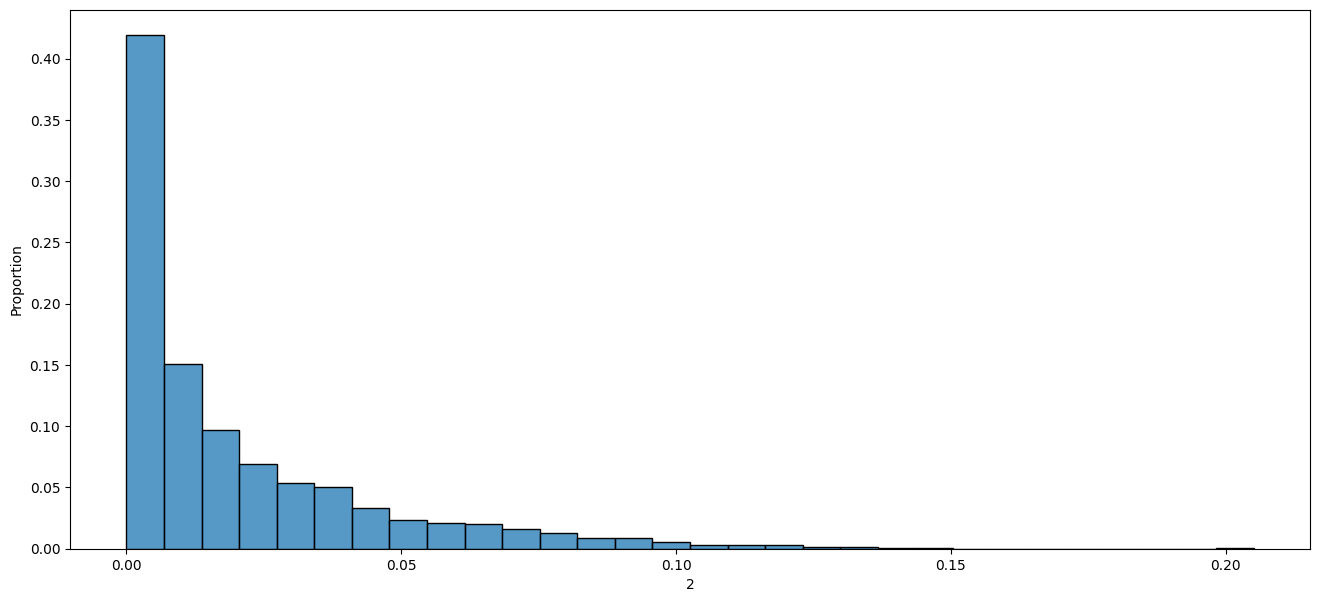

------  Analyse de la variable 3 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 0.2 
Unique values : 4886.0


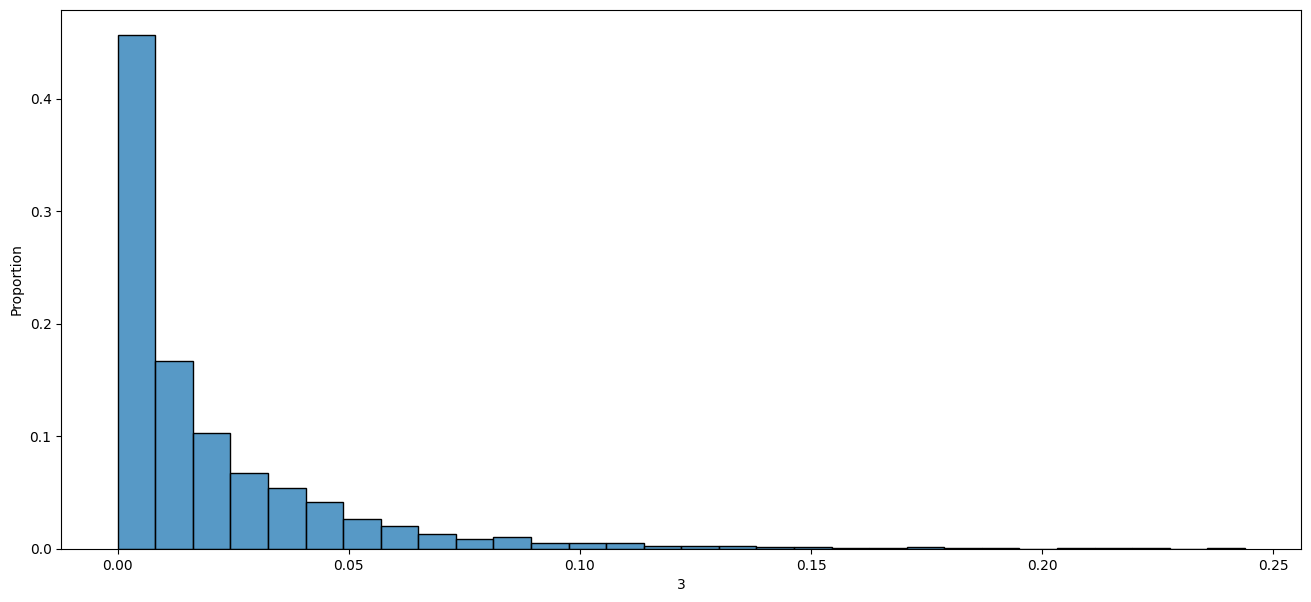

------  Analyse de la variable 4 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 0.2 
Unique values : 4890.0


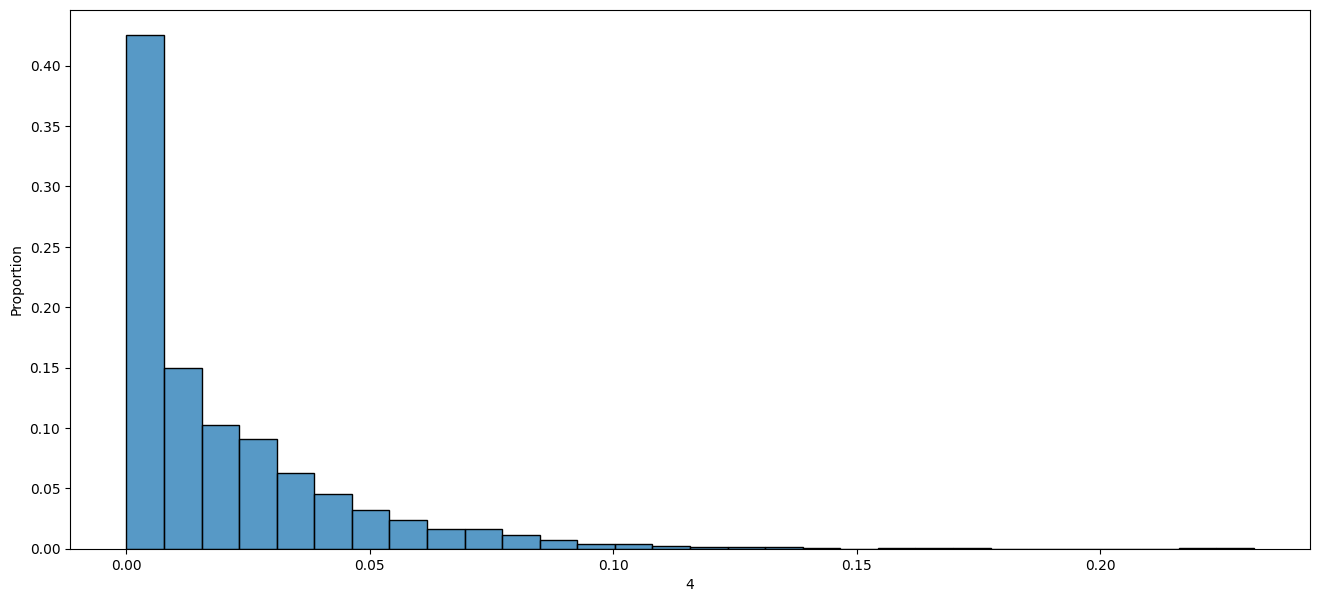

------  Analyse de la variable 5 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 0.7 
Unique values : 4890.0


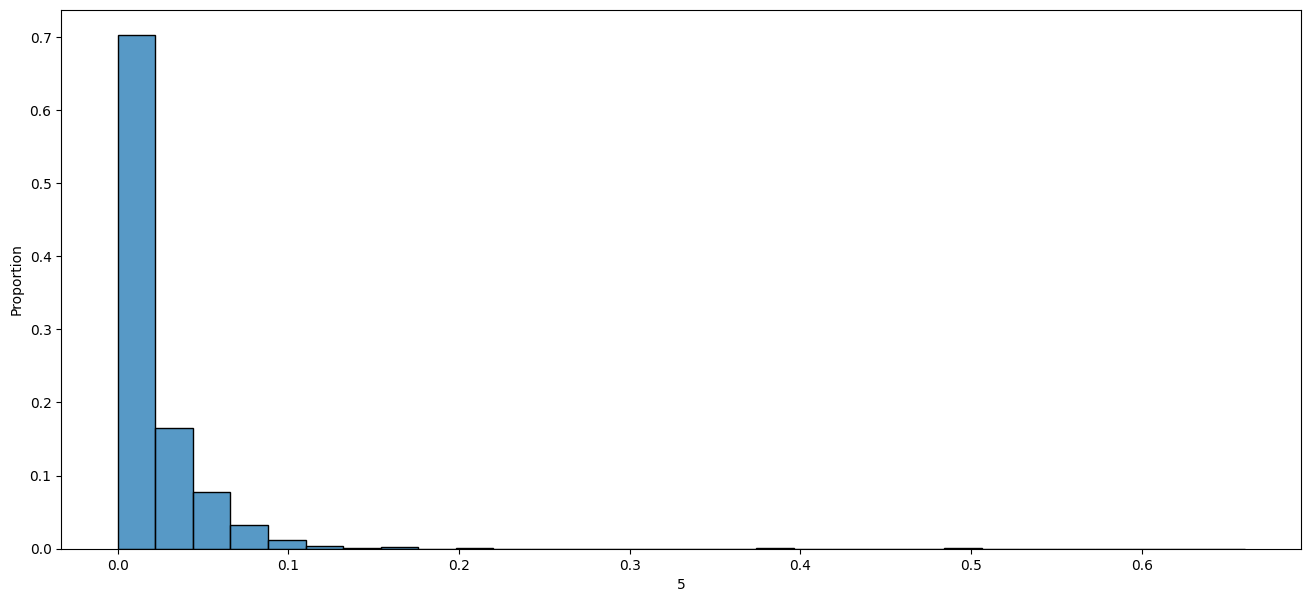

------  Analyse de la variable 6 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 2.5 
Unique values : 4889.0


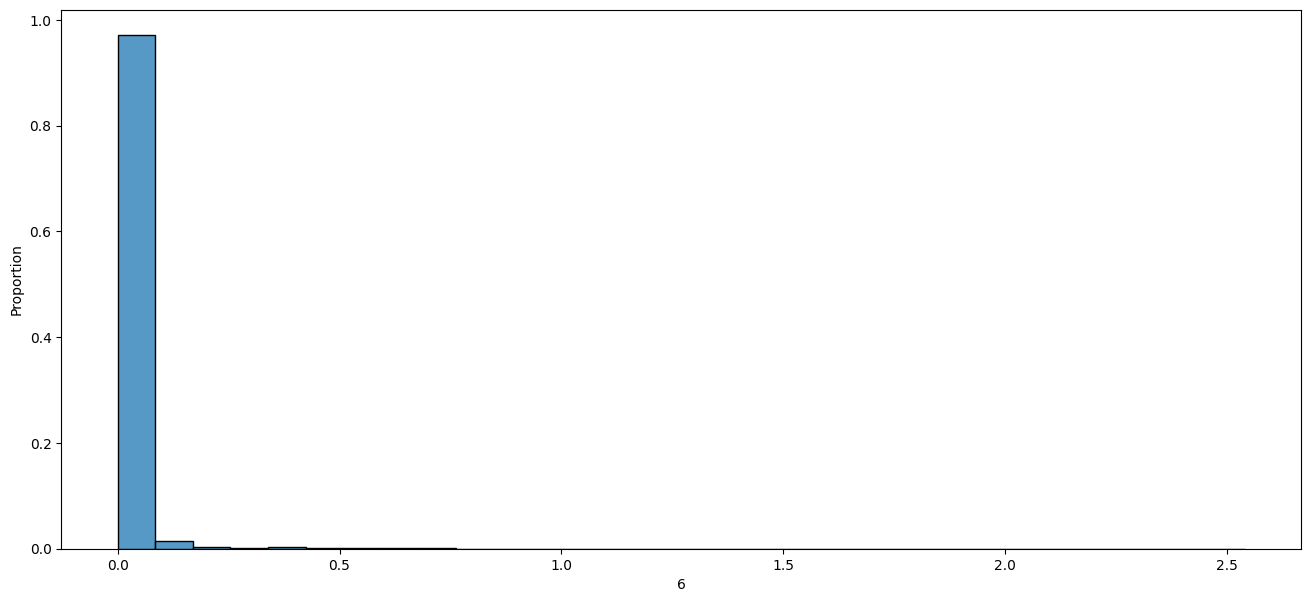

------  Analyse de la variable 7 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 1.1 
Unique values : 4891.0


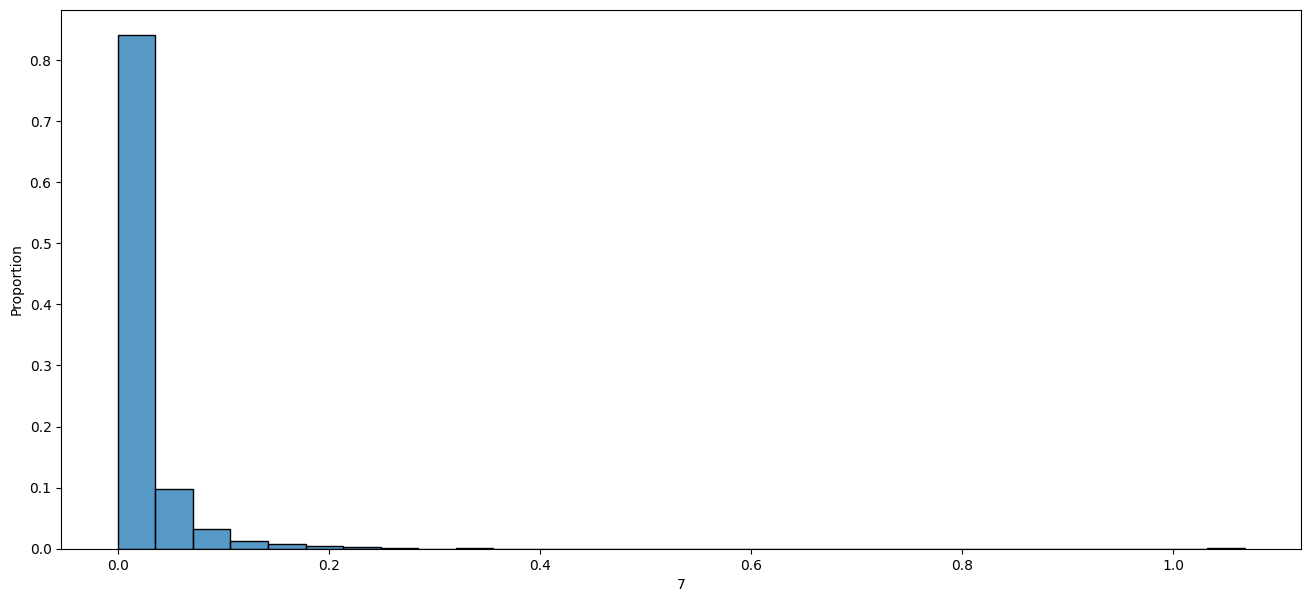

------  Analyse de la variable 8 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 1.1 
Unique values : 4891.0


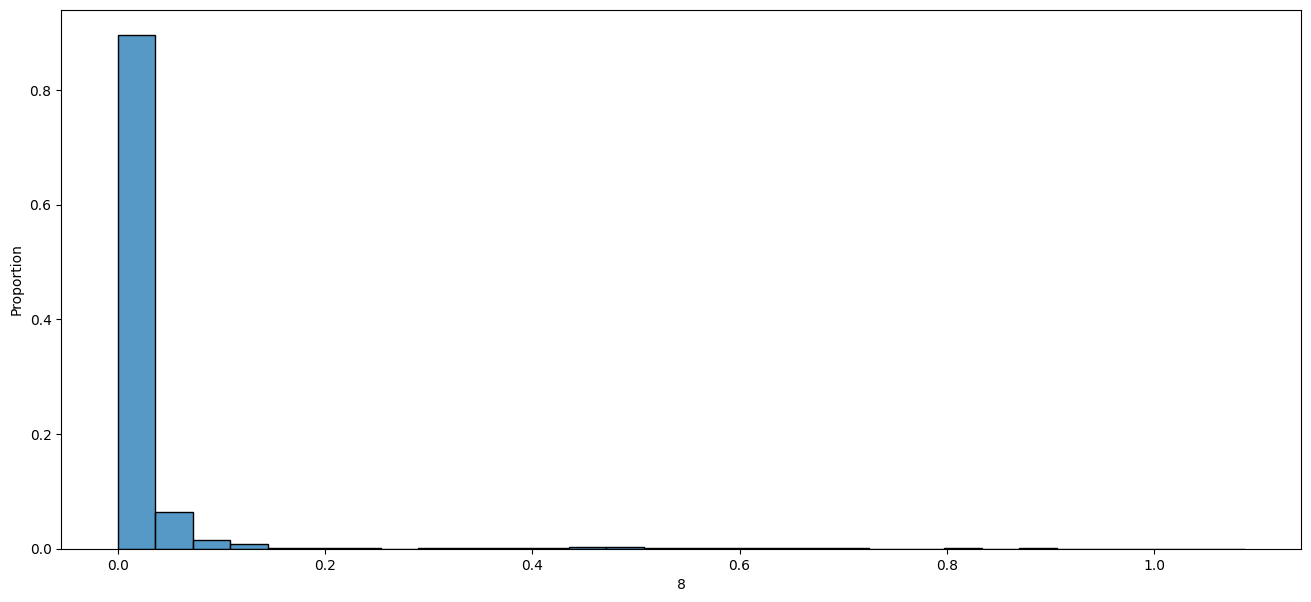

------  Analyse de la variable 9 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 2.0 
Unique values : 4890.0


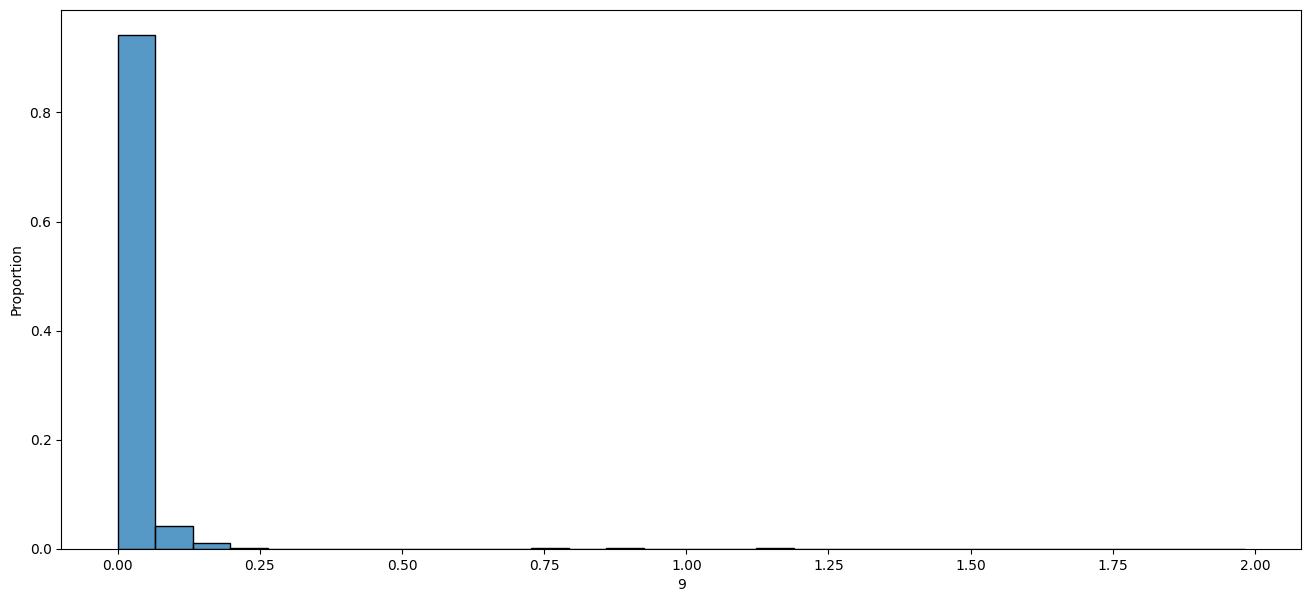

------  Analyse de la variable 10 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 1.3 
Unique values : 4890.0


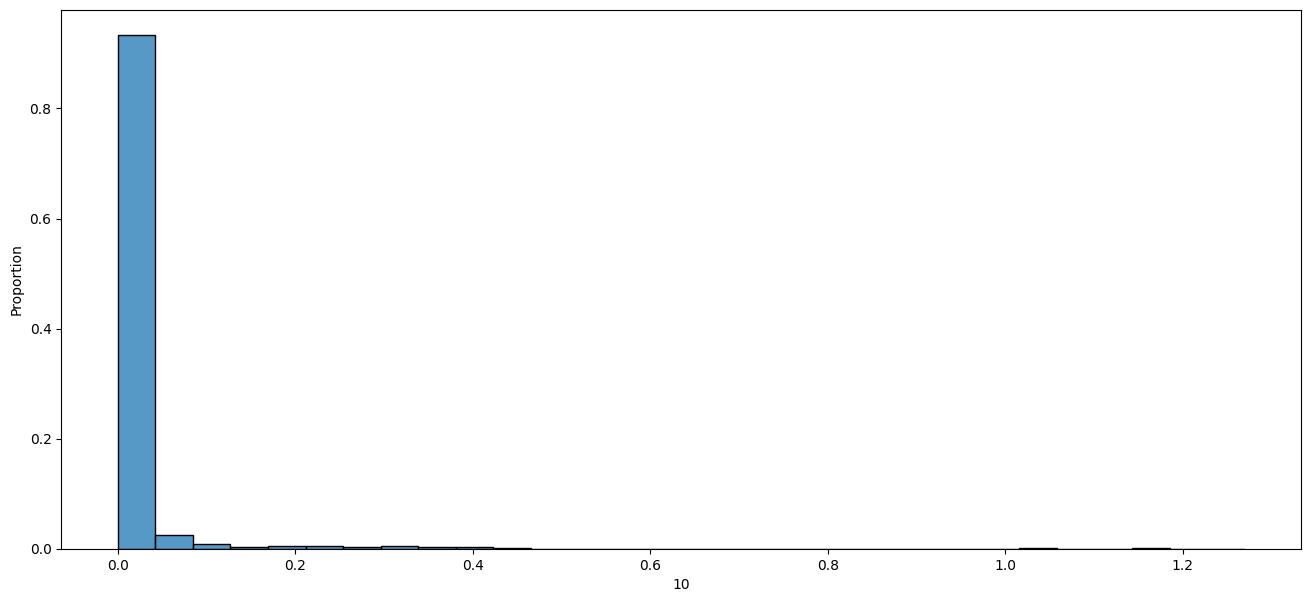

------  Analyse de la variable 11 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 1.8 
Unique values : 4891.0


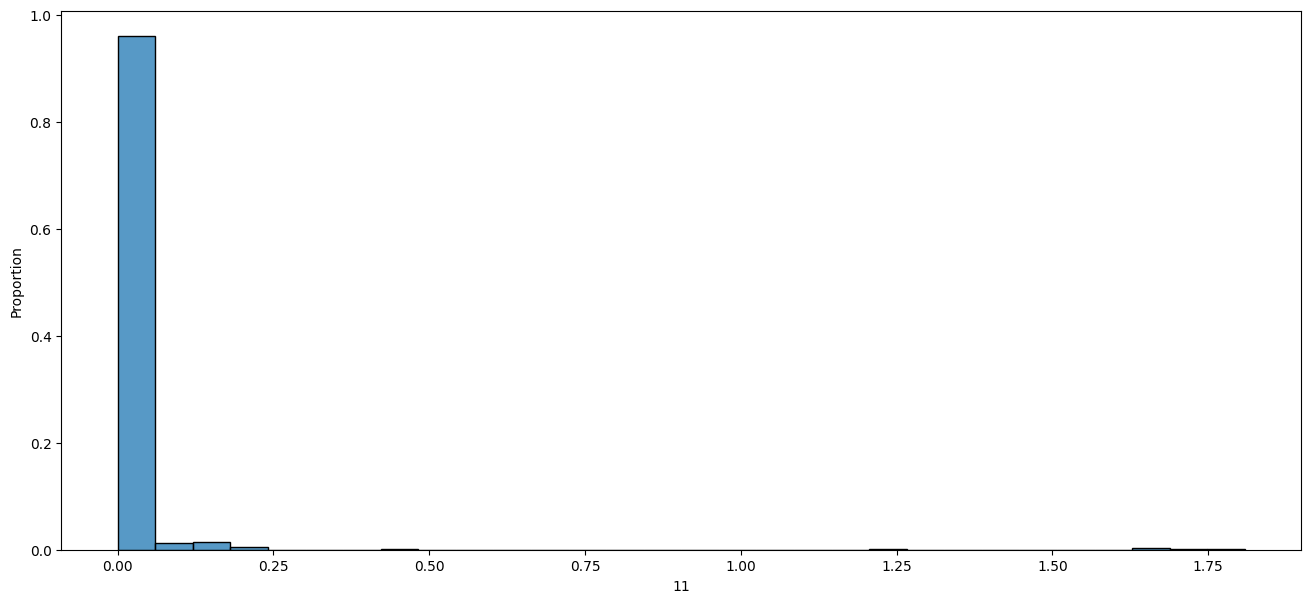

------  Analyse de la variable 12 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 1.7 
Unique values : 4889.0


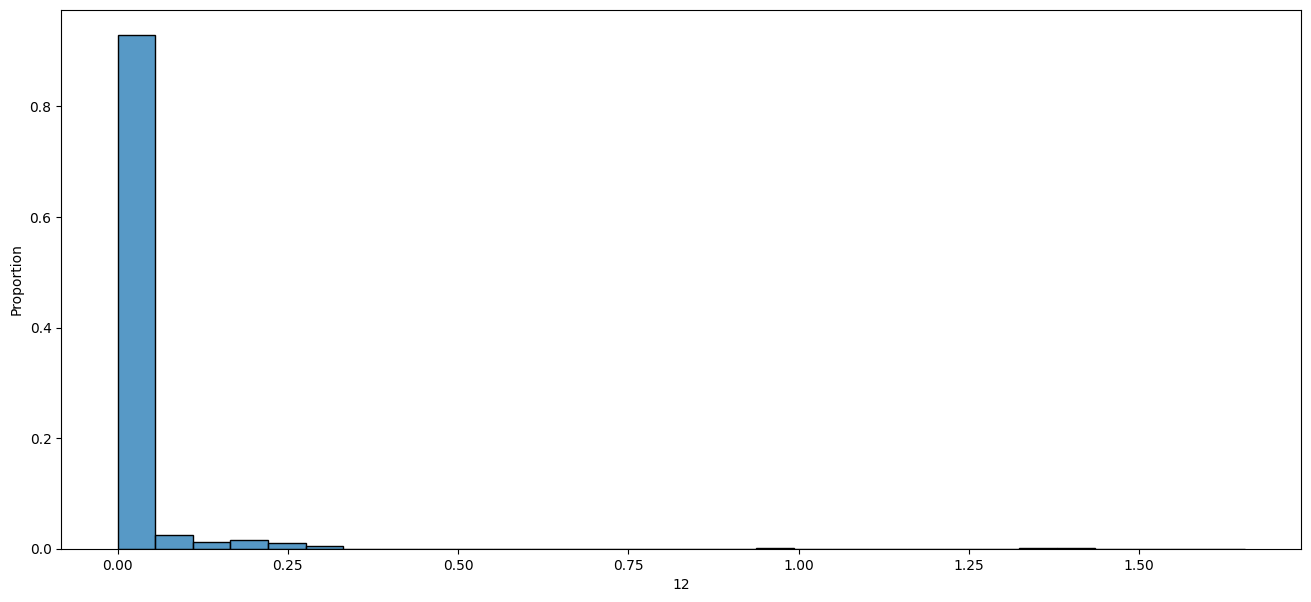

------  Analyse de la variable 13 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 4.1 
Unique values : 4891.0


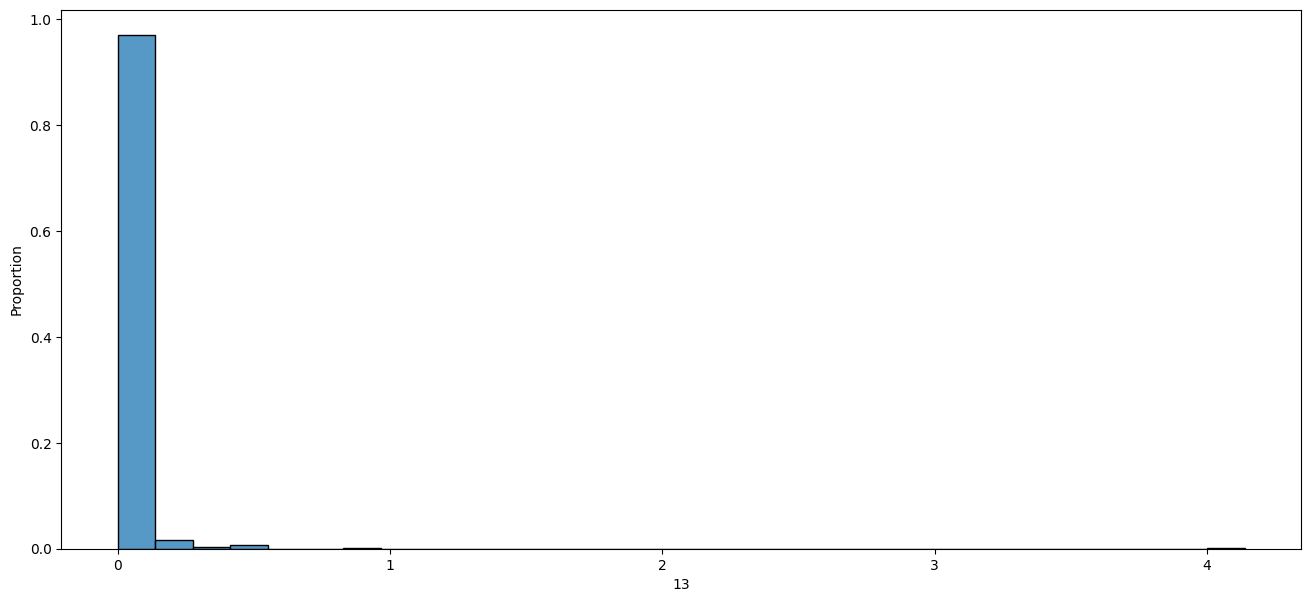

------  Analyse de la variable 14 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 8.2 
Unique values : 4891.0


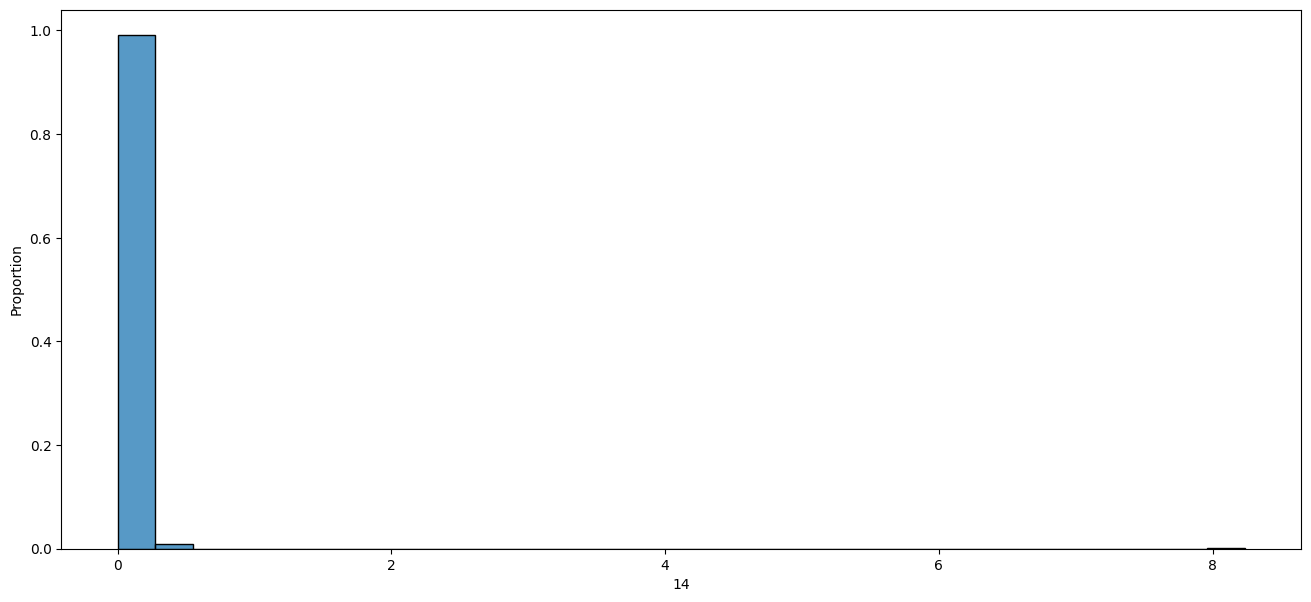

------  Analyse de la variable 15 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 1.7 
Unique values : 4890.0


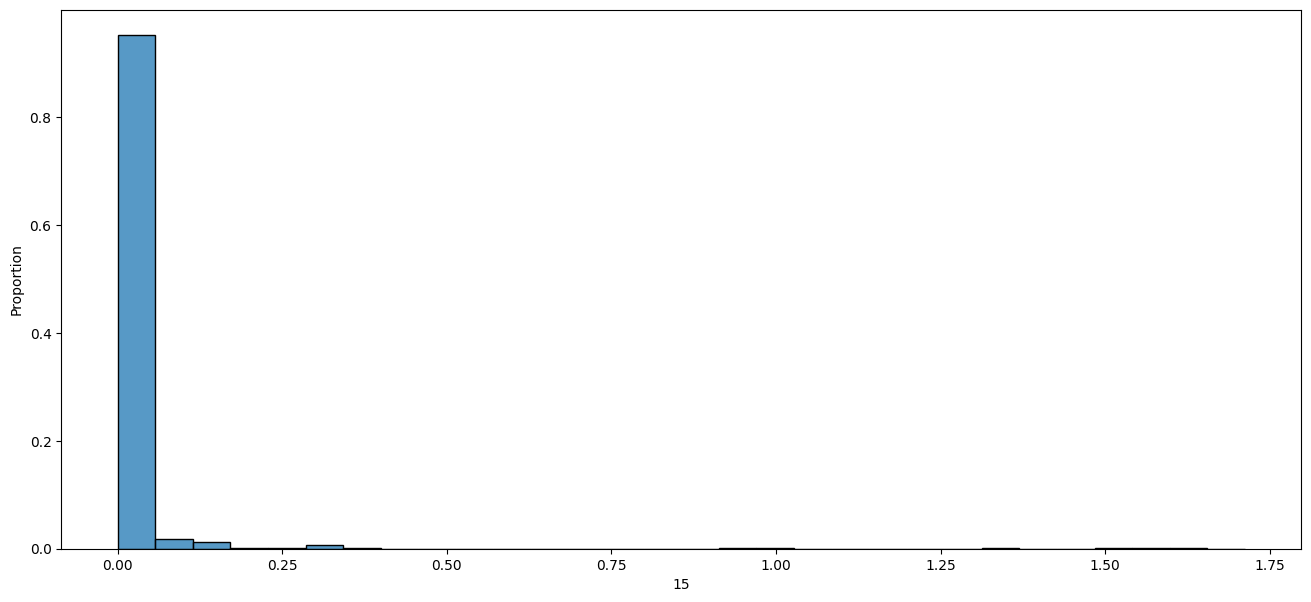

------  Analyse de la variable 16 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 4.0 
Unique values : 4891.0


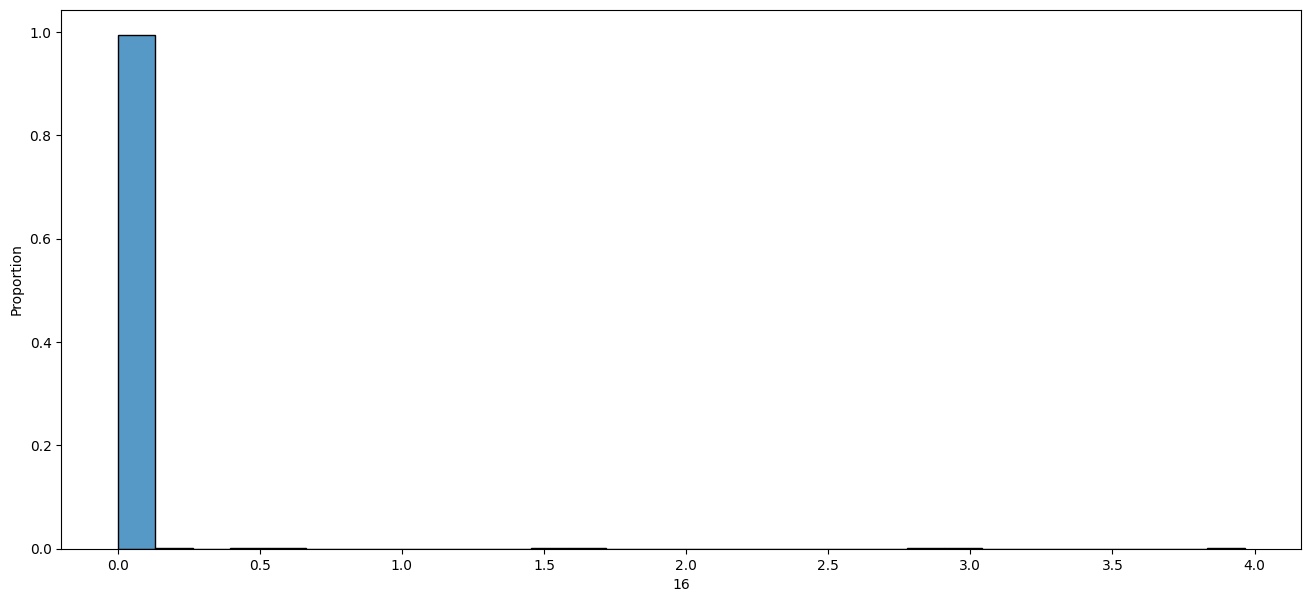

------  Analyse de la variable 17 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 10.9 
Unique values : 4891.0


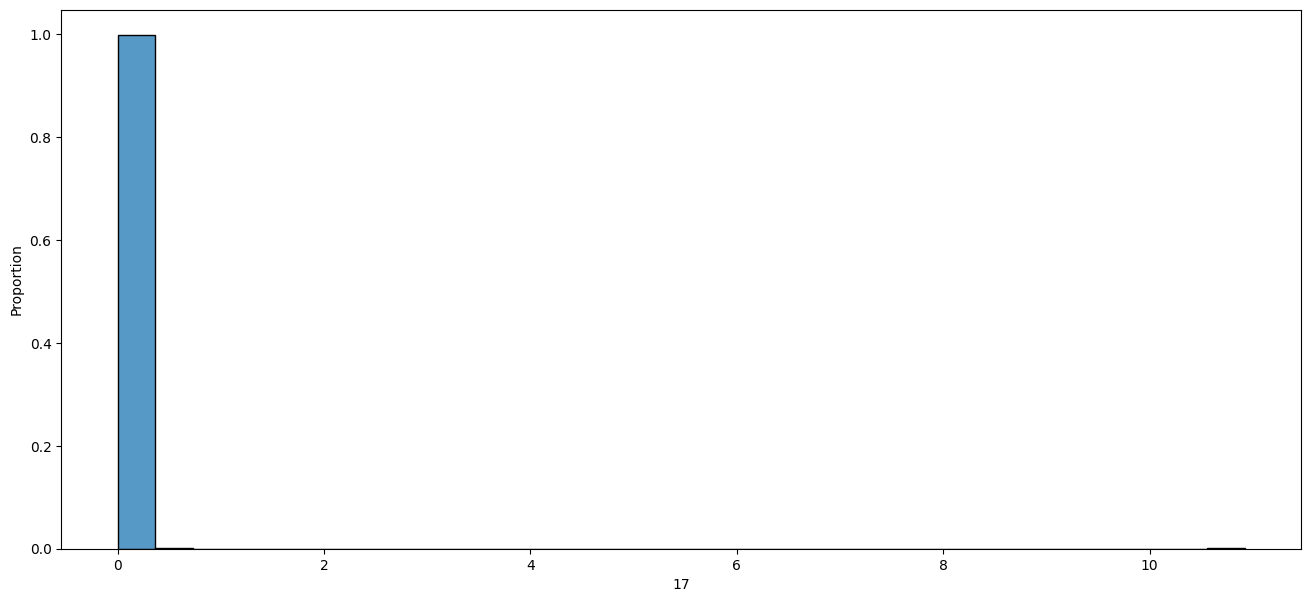

------  Analyse de la variable 18 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 1.2 
Unique values : 4891.0


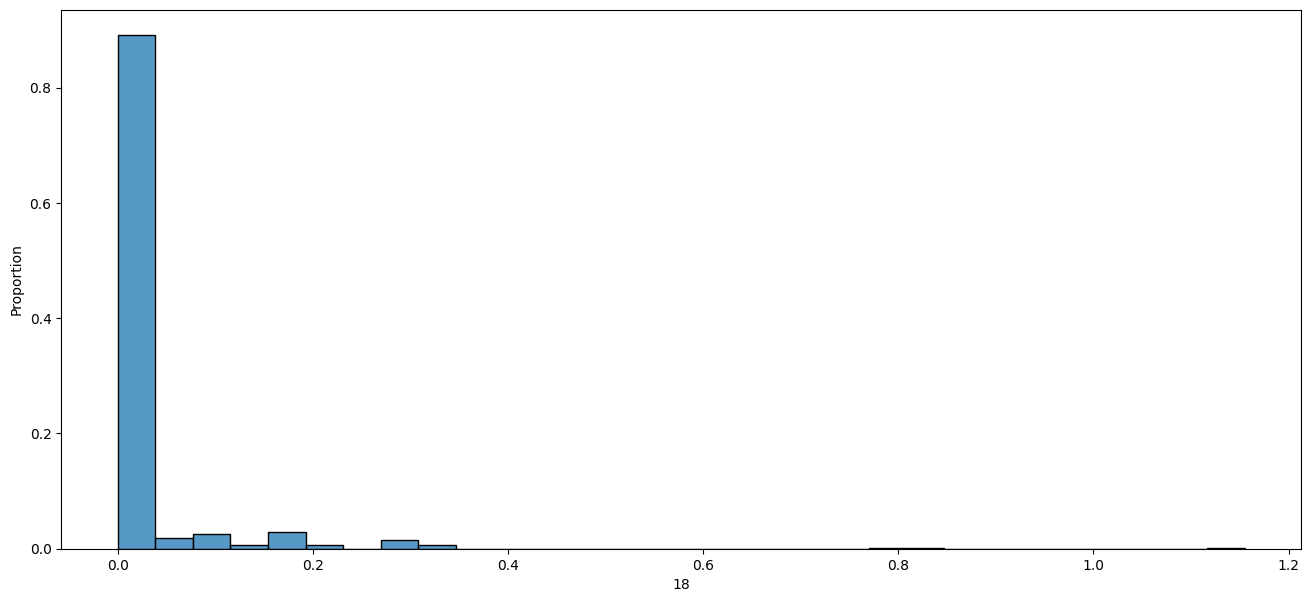

------  Analyse de la variable 19 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.0 
Médiane : 0.0 
Maximum : 3.0 
Unique values : 4891.0


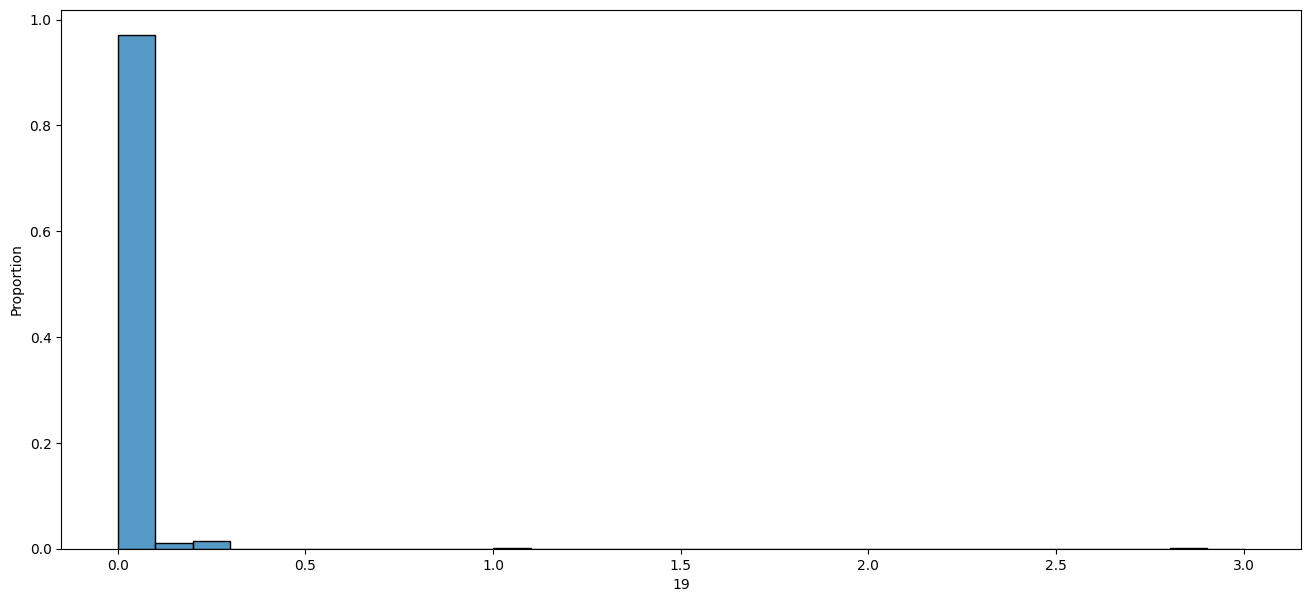

In [99]:
TransformData.plotnum(df_acm_contribution_row, list(df_acm_contribution_row.columns))

In [104]:
mca.plot(
    df_acm.sample(5000, random_state=1),
    x_component=0,
    y_component=1,
    show_column_markers=True,
    show_row_markers=False,
    show_column_labels=True,
    show_row_labels=False,
)

alt.LayerChart(...)

## Testing Regressions

In [ ]:
# preprocessing before regressions
df_regress = df_final[
    [x for x in list(df_final.columns) if x.startswith('client') | x.startswith('nb_decomptes_') | x.startswith('remb_alptis_') | x.startswith('reste_a_charge_') 
    | x.startswith('target_resiliation_6mois')]
    ]
df_regress
df_regress.shape

(132576, 53)

In [122]:
# categorical variables
list_categorical = df_regress.select_dtypes(include=["object","bool"]).columns.to_list()

# Exclusion list categorical
exclusion = ['client_code', 'client_code_postal', 'client_departement', 'client_departement_avant_changement_12_mois', 'client_millesime_tarifaire_produit', 
'client_date_debut_effet_garantie', 'client_mode_paiement', 'client_frequence_paiement','client_nom_banque', 'client_nps_date_reponse_n', 'client_nps_verbatim_n', 
'client_nps_date_reponse_n_moins1', 'client_nps_verbatim_n_moins1']
for elem in exclusion:
    list_categorical.remove(elem)
list_categorical

['client_sexe_souscripteur',
 'client_ro_souscripteur',
 'client_a_conjoint',
 'client_structure_familiale',
 'client_a_garantie_prevoyance',
 'client_produit',
 'client_garantie_base',
 'client_garantie_base_plus_options',
 'client_zone_tarifaire',
 'client_type_zone_tarifaire',
 'client_est_contrat_madelin']

In [127]:
# numerical variables
list_numerical = df_regress.select_dtypes(exclude=["object","bool"]).columns.to_list()

# Exclusion
exclusion = ['client_nb_assures_contrat', 'client_nps_note_reco_n', 'client_nps_note_reco_n_moins1', 'target_resiliation_6mois']
for elem in exclusion:
    list_numerical.remove(elem)
    
list_numerical

['client_age_souscripteur',
 'client_nb_enfants',
 'client_anciennete_contrat_annees',
 'client_cotisations_annualisees_n_moins2',
 'client_cotisations_annualisees_n_moins1',
 'client_cotisations_annualisees_n',
 'client_cotisations_annualisees_n_plus1',
 'nb_decomptes_hospitalisation',
 'nb_decomptes_soins_medicaux',
 'nb_decomptes_pharmacie',
 'nb_decomptes_optique',
 'nb_decomptes_dentaire',
 'nb_decomptes_divers',
 'remb_alptis_hospitalisation',
 'remb_alptis_soins_medicaux',
 'remb_alptis_pharmacie',
 'remb_alptis_optique',
 'remb_alptis_dentaire',
 'remb_alptis_divers',
 'reste_a_charge_hospitalisation',
 'reste_a_charge_soins_medicaux',
 'reste_a_charge_pharmacie',
 'reste_a_charge_optique',
 'reste_a_charge_dentaire',
 'reste_a_charge_divers']

In [129]:
# Logistic regression on numerical variables

## Definig feature-targer
X = df_regress[list_numerical]
y = df_regress['target_resiliation_6mois']

## Scaling feature
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

## Training model
logreg = sklearn.linear_model.LogisticRegression(class_weight='balanced', max_iter=100, solver='sag')
logreg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
# Score :
logreg1.score(X=X, y=y)

0.6597423364711562